# Lecture 9: Counterfactual Design for Interchange Interventions

Recall two earlier course ideas:
- From **Lecture 3** ([slides](https://cs221m.github.io/materials/03_slides.pdf), [notebook](https://colab.research.google.com/github/rkapur102/cs221m-course/blob/main/03_behavioral_analysis.ipynb)), we learned the logic of controlled variation. Small, structured changes in the input can reveal which features a model is actually using. 
- From **Lecture 5** ([slides](https://cs221m.github.io/materials/05_slides.pdf), [notebook](https://colab.research.google.com/github/rkapur102/cs221m-course/blob/main/07_causal_abstraction_i.ipynb)), and **lecture 8** ([slides](https://cs221m.github.io/materials/08_slides.pdf), [notebook](https://colab.research.google.com/github/rkapur102/cs221m-course/blob/main/08_causal_mediation_analysis.ipynb)), we learned how to apply interchange interventions to identify causally relevant components in a model.

This notebook studies a methodological question at the center of causal interpretability: **how to construct base and source examples so that an interchange intervention bears on a localization claim.**

A localization claim says that a hidden-state site in a low-level model $\mathcal{L}$ plays the causal role of a variable in a high-level causal model $\mathcal{H}$. Interchange interventions are the main tool we use to test such claims. 

Our central question here is:

> How should we choose **base and source pairs** so that an interchange intervention experiment provides evidence that a site in $\mathcal{L}$ realizes a chosen variable in $\mathcal{H}$?

Each part of the notebook follows the same procedure: 

1. Specify a **task-level causal model**, 
2. Design **counterfactual datasets**, 
3. Evaluate those datasets at *the causal-model level*, and finally 
4. Interpret the results of *low-level* neural interchange interventions. 

The aim is to understand **which dataset contrast licenses which localization claim**.


### ✍️ Learning goals

By the end of the notebook, you should be able to:

- describe a task in terms of **causal variables** and **structural relationships**
- explain the role of a **counterfactual dataset** in an interchange-intervention experiment
- distinguish between the three dataset roles — **`<V>_targeted`**, **`<V>_isolated`**, and **`random`** — and know what each is evidence for
- check a dataset at the **causal-model level** before running neural interventions
- interpret an **IIA heatmap** as evidence about where a variable may be represented in the network

## 📘 Core concepts and notation


We will use the following terms consistently.

- **Causal model**: a set of variables together with mechanisms that compute each variable from its parents.
- **Trace**: one concrete run of the causal model, including the input variables, intermediate variables, and final output.
- **Counterfactual example**: a base trace together with one or more counterfactual traces.
- **Interchange intervention**: an intervention that replaces the value of a variable in the base trace with the value of the corresponding variable from a counterfactual trace.
- **IIA (interchange intervention accuracy)**: the agreement between the patched language model and the patched causal model.

Formally,

Let $\mathcal{A}$ be an **algorithmic causal model** for a task, and let $\mathcal{N}$ be the corresponding **network-level model**. A run of the algorithm on input $i$ is written $\mathcal{A}(i)$, and a run of the network on prompt $x$ is written $\mathcal{N}(x)$.

### What is an intervention?

An **intervention** (written $\mathcal{A}_{X \leftarrow x}$) forcibly sets a variable $X$ to a specific value $x$, **breaking the causal link from its parents**.

Interventions are the key tool for testing **causal**, not merely correlational, claims.

### What is an interchange intervention?

An **interchange intervention** is a special intervention in which the intervened value is taken from a **source run** rather than chosen externally. Given a base input $b$, a source input $s$, and an algorithm variable $V$, the algorithmic interchange is written

$$
\mathcal{A}(b)_{V \leftarrow \mathcal{A}(s)}
$$

At the network level, if $\Pi_V$ denotes the candidate set of low-level sites aligned with $V$, the corresponding network interchange is

$$
\mathcal{N}(b)_{\Pi_V \leftarrow \mathcal{N}(s)}
$$

In this notebook we typically test **one candidate site at a time**, so $\Pi_V$ often contains a single layer-position site.

### Localization hypotheses

A **localization hypothesis** says that a candidate site $\Pi_V$ in $\mathcal{N}$ plays the causal role of an algorithm variable $V$ in $\mathcal{A}$. Causal abstraction is a theory of whether the network interchange and the corresponding algorithmic interchange agree on their counterfactual behavior.

When the algorithm input and the model prompt are represented in different formats, we write $\rho$ for the input translation from the task-level representation to the prompt consumed by the language model. In the code, this translation is handled by the task templates and rendering functions.

### Causal abstraction in one equation

More generally, an alignment $(\Pi, \pi)$ between $\mathcal{A}$ and $\mathcal{N}$ induces the trace translation $\tau_\pi$, the intervention translation $\omega_\pi$, and the input translation $\rho_\pi$. In the notation of the earlier notebook, causal abstraction asks whether

$$
\tau_\pi(\textsf{Run}(\mathcal{N}_{X \leftarrow x}(i))) = \textsf{Run}(\mathcal{A}_{\omega_\pi(X \leftarrow x)}(\rho_\pi(i)))
$$

for all inputs $i$ and all interventions $X \leftarrow x$.

In this notebook we focus on the special case of **interchange interventions** and evaluate agreement at the output level. That is the role played by IIA.

### Interchange Intervention Accuracy (IIA)

Following the earlier notebook, we measure alignment quality using **Interchange Intervention Accuracy (IIA)** over a dataset of base-source pairs:

$$
\mathrm{IIA}(V,\Pi_V;\mathcal{D}) = \frac{1}{|\mathcal{D}|}
\sum_{(b,s) \in \mathcal{D}}
\mathbf{1}\!\left[
\pi_O\!\left(\mathcal{N}(b)_{\Pi_V \leftarrow \mathcal{N}(s)}\right) = \mathcal{A}(\rho(b))_{V \leftarrow \mathcal{A}(\rho(s))}
\right].
$$

Here:

- $\mathcal{D}$ is a dataset of base/source pairs,
- $V$ is the algorithm variable being tested,
- $\Pi_V$ is the candidate low-level site or set of sites aligned with $V$, and
- $\pi_O$ reads the task output from the patched network run.

In other words, IIA measures how often the translated network interchange agrees with the corresponding algorithmic interchange on a given dataset. **IIA = 1.0 means perfect causal abstraction** on the evaluation dataset - for every base-source pair, the translated network interchange matches the algorithm interchange. 

## 🧭 Notebook structure

The notebook has three parts.

1. **Hierarchical equality** —  The model is given four inputs and needs to determine whether the relation between the first two inputs agrees with the relation between the second two inputs.
2. **MCQA** — The model is given a multiple-choice question with labeled options and needs to use the content of the question to identify the correct option and return its label.
3. **Entity binding** — The model is given a short set of relational statements and needs to recover the entity that stands in the queried relation to the entity mentioned in the question.

Each part of the notebook follows the same sequence.

1. **Specify a high-level causal model.**  
   We write down the variables, mechanisms, and candidate localization hypotheses relevant to the task.

2. **Construct counterfactual datasets.**  
   We build base/source pairs that induce particular intervention patterns on the variables of the high-level model.

3. **Evaluate the dataset at the high level before patching the low level.**  
   We ask whether the dataset changes the target variable, whether it changes a competing variable, and whether it distinguishes the corresponding high-level hypotheses.

4. **Filter to examples that the language model handles correctly.**  
   We keep examples on which the behavior of $\mathcal{L}$ and the high-level model agree in the ordinary, non-intervened setting. This gives the neural experiment a meaningful task-level reference point.

5. **Run interchange interventions on hidden states.**  
   We patch one layer-position site at a time and compare the patched low-level model to the patched high-level model.

6. **Interpret IIA relative to the dataset contrast.**  
   A heatmap is not evidence in isolation. It is evidence only relative to the counterfactual contrast induced by the dataset.

## 0️⃣ Setup

Run this code to get started!

In [1]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
    !git clone https://github.com/rkapur102/cs221m-course.git
    %cd cs221m-course
    !pip install -r requirements/09_counterfactual_design.txt
else:
    pio.renderers.default = "plotly_mimetype+png"
    !plotly_get_chrome -y

clear_output()

To keep the code short and sweet, we'll rely on utility functions in `utils/lecture_09_utils` (provided we cloned the [course github](https://github.com/rkapur102/cs221m-course.git) above).

In [2]:
import random
import numpy as np

from causalab.causal.causal_model import CausalModel
from causalab.causal.trace import Mechanism, input_var

from utils.lecture_09_utils import (
    set_seed,
    make_dataset,
    show_localization_view,
    display_change_rate_table,
    display_effect_rate_table,
    display_localization_scorecard,
    plot_dataset_criteria_bars,
    default_layers,
    run_patching_for_datasets,
    plot_iia_target_control_random,
    build_counterfactual_dataset,
    print_counterfactual_pair_text,
    print_one_pair_per_dataset,
    print_confounding_and_nonconfounding,
    load_activation_patching_pipeline,
    load_entity_binding_pipeline,
    filter_and_report,
    hier_metric,
    mcqa_metric,
    build_hier_token_positions,
    build_mcqa_token_positions,
    install_entity_binding_shims,
    make_entity_binding_generators,
    build_entity_binding_token_positions,
    diagnose_entity_binding_sites,
)

set_seed(0)

We'll load the model below. For this lecture, we'll focus on a ~1B model. 

In [3]:
FILTER_BATCH_SIZE = 4
PATCH_BATCH_SIZE = 4

pipeline, _device = load_activation_patching_pipeline(
    max_new_tokens=5,
    max_length=768,
)

clear_output()

print(pipeline.model.name_or_path)

meta-llama/Llama-3.2-1B-Instruct


## 📐 Counterfactual dataset design

### Overview

The central methodological question is not just whether a dataset contains counterfactual pairs. It is whether those pairs let us evaluate a localization hypothesis in a way that is *causally diagnostic*.

We work in the notation of the earlier course notebooks. For a base/source pair $(b,s)$, let $V$ be the target algorithm variable and let $O$ be the output variable of the causal model.

Define the output predicted by an interchange intervention on $V$ as

$$
Y_V(b,s)
:=
\mathcal{A}(\rho(b))_{V \leftarrow \mathcal{A}(\rho(s))}[O],
$$

and define the ordinary output on the base input as

$$
Y_{\mathrm{base}}(b)
:=
\mathcal{A}(\rho(b))[O].
$$

There are three criteria to determine whether the pair of inputs $(b, s)$ gives us a diagnostic about the variable $V$.

#### 1. Variable-level change

First, the pair should actually change the value of the target variable between the base and source runs:

$$
\Delta_V(b,s)
:=
\mathbf{1}\!\left[
\mathcal{A}(\rho(b))[V]
\neq
\mathcal{A}(\rho(s))[V]
\right].
$$

This is the most basic requirement. If $V$ takes the same value in the base and source runs, then the pair does not test anything about how the model represents $V$.

#### 2. Output-changing test intervention

Variable-level change is still not enough. A pair can change $V$ while still leaving the output unchanged. For localization, what matters is whether intervening on $V$ yields a *different predicted value of the output*.

So we ask whether the interchange on $V$ produces an output different from the ordinary base run:

$$
Y_V(b,s) \neq Y_{\mathrm{base}}(b).
$$

When this holds, the pair induces an **output-changing test intervention** on $V$, with respect to the output variable $O$. Equivalently, the associated **test counterfactual** is that if $V$ had been set to its source value, then the output would have been different from its actual base value.

The question isn't just whether the variable changed. It's whether the causal model predicts a *different output* after that intervention.

#### 3. Distinguishability relative to a competing variable $W$

Even when intervening on $V$ changes the output, that still may not identify $V$ as the right localization target. Another variable $W$ may induce exactly the same output change on the same pair.

So we also ask whether the pair distinguishes the target hypothesis from a competing hypothesis:

$$
Y_V(b,s) \neq Y_W(b,s),
$$

where

$$
Y_W(b,s)
:=
\mathcal{A}(\rho(b))_{W \leftarrow \mathcal{A}(\rho(s))}[O].
$$

If instead

$$
Y_V(b,s) = Y_W(b,s),
$$

then the pair is **confounding** for the purpose of distinguishing the two localization hypotheses. In that case, a high neural IIA score is compatible with both stories: the patched site may realize $V$, or it may realize $W$.

This criterion is especially important because we do **not** know in advance where in the network the target variable is realized. Discovering that is the point of the intervention analysis. For that reason, a high IIA score is interpretable as evidence for localizing $V$ only when the dataset rules out the relevant alternatives at the level of the causal model.

At the dataset level, we summarize this with the **distinguishability rate**

$$
\mathrm{Dist}_{V,W}(\mathcal{D}) =
\frac{1}{|\mathcal{D}|}
\sum_{(b,s)\in\mathcal{D}}
\mathbf{1}\!\left[
Y_V(b,s) \neq Y_W(b,s)
\right].
$$

This is the fraction of pairs in $\mathcal{D}$ that separate the $V$-localization hypothesis from the $W$-localization hypothesis.

### Implementing diagnostics

Before looking at any neural heatmap, we first evaluate the dataset at the level of the causal model. This is essential. If a dataset fails to satisfy the relevant causal-model criteria, then even a visually striking low-level pattern may not support a clear localization claim.

For a dataset $\mathcal{D}$ and target variable $V$, we report three main rates over pairs $(b,s)\in\mathcal{D}$.

- **Criterion (1):** the rate at which $V$ differs between the base and source runs.
- **Criterion (2):** the rate at which the interchange intervention on $V$ is an output-changing test intervention, that is, the rate at which
  $$
  Y_V(b,s) \neq Y_{\mathrm{base}}(b).
  $$
- **Criterion (3):** the rate at which the interchanges on $V$ and $W$ predict different outputs, that is, the rate at which
  $$
  Y_V(b,s) \neq Y_W(b,s).
  $$

The analogous rates for $W$ also appear for context. Those are diagnostic rather than required.

What matters is the progression across the three datasets.

- `random` may satisfy any of the three criteria only incidentally.
- `<V>_targeted` is designed to satisfy (1) and (2).
- `<V>_isolated` is designed to satisfy (1), (2), and (3).

Of these three criteria, **criterion (3)** is the most important for interpreting localization results. When criterion (3) is weak, high IIA at a neural site does not by itself tell us that the site realizes $V$. It may instead reflect a hypothesis that is equally compatible with $V$ and with the competing variable $W$.

### Reading diagnostics

Each row reports one diagnostic as a percentage of pairs in the dataset, and each row contains one bar per dataset.

The rows are:

1. **$\Delta V$**  
   Fraction of pairs for which the target variable changes:
   $$
   \mathcal{A}(\rho(b))[V] \neq \mathcal{A}(\rho(s))[V].
   $$

2. **$\texttt{patch}(V) \rightarrow \Delta Y$**  
   Fraction of pairs for which the interchange on $V$ is an output-changing test intervention:
   $$
   Y_V(b,s) \neq Y_{\mathrm{base}}(b).
   $$

3. **$\Delta W$** and **$\texttt{patch}(W) \rightarrow \Delta Y$**  
   The analogous rates for the competing variable $W$. These are diagnostic. They show how much the competing variable moves, and how often its intervention also changes the output, in the same dataset.

4. **$Y_V(b,s) \neq Y_W(b,s)$**  
   Fraction of pairs that distinguish the two localization hypotheses. This is the identification-relevant row.

A typical pattern is:

- `random`: middling or low across rows, by construction.
- `<V>_targeted`: high on $\Delta V$ and on $\texttt{patch}(V) \rightarrow \Delta Y$, but often also high on the analogous rows for $W$, since $W$ is not controlled.
- `<V>_isolated`: high on $\Delta V$, on $\texttt{patch}(V) \rightarrow \Delta Y$, and on $Y_V \neq Y_W$, with the diagnostic rows for $W$ typically reduced relative to `<V>_targeted`.

That final row, $Y_V(b,s) \neq Y_W(b,s)$, is the one to consult first when asking whether a dataset can support a localization claim rather than merely a suggestive heatmap.

### Tasks in this notebook

For each task, we design three datasets.

1. **`random`** samples base-source pairs from the input space without enforcing a particular causal contrast.
2. **🎯 `<V>_targeted`** is designed to satisfy criteria (1) and (2): the target variable changes, and the intervention on $V$ induces a different output.
3. **🟣 `<V>_isolated`** is designed to satisfy criteria (1), (2), and (3): it changes $V$, induces a different output, and distinguishes $V$ from a competing variable $W$ as cleanly as possible.

Throughout the notebook, the relevant target and competing variables are:

| Part | Task | Target $V$ | Competing variable $W$ |
| --- | --- | --- | --- |
| 1 | Hierarchical equality | `left_eq` | `right_eq` |
| 2 | MCQA | `answer_position` | `answer` |
| 3 | Entity binding | `query_entity` | `positional_query_group` |

## 1️⃣ Hierarchical equality


### Overview

The **hierarchical equality** task was introduced earlier in the course as the running example for interventions and causal abstraction.

In the earlier notebook, the high-level algorithm was written as $\mathcal{A}$ with inputs $I_1,I_2,I_3,I_4$, intermediate variables $E_1,E_2$, and output $O$. In the code used here, the corresponding variables are:

- $I_1,I_2 \leftrightarrow$ `left_a`, `left_b`
- $I_3,I_4 \leftrightarrow$ `right_a`, `right_b`
- $E_1 \leftrightarrow$ `left_eq`
- $E_2 \leftrightarrow$ `right_eq`
- $O \leftrightarrow$ `raw_output`

The high-level computation is the same one you saw earlier:

$$
E_1 = (I_1 = I_2),
\qquad
E_2 = (I_3 = I_4),
\qquad
O = (E_1 = E_2).
$$

So the task asks whether the two pairs instantiate the same equality relation.

### Localization hypotheses

We study a single localization question, instantiated as in the global table:

- **Target $V = E_1 \leftrightarrow$ `left_eq`.** $H_V$ is the hypothesis that some hidden-state site in $\mathcal{L}$ plays the causal role of `left_eq`.
- **Alternative $W = E_2 \leftrightarrow$ `right_eq`.** $W$ is the competing variable against which the dataset must distinguish $V$. The role of $W$ in the analysis is to set the bar for criterion (3): a high IIA on a candidate site is taken as evidence for $H_V$ only when the dataset has shown, at the causal-model level, that interchanging $V$ and interchanging $W$ produce different outputs.

Because the causal structure is so small, this task lets us check **non-trivial change in $Y$**, **confounding**, and **dataset-level distinguishability** exactly. That makes it a useful warm-up for the later sections, where the same questions are harder to answer from inspection alone.

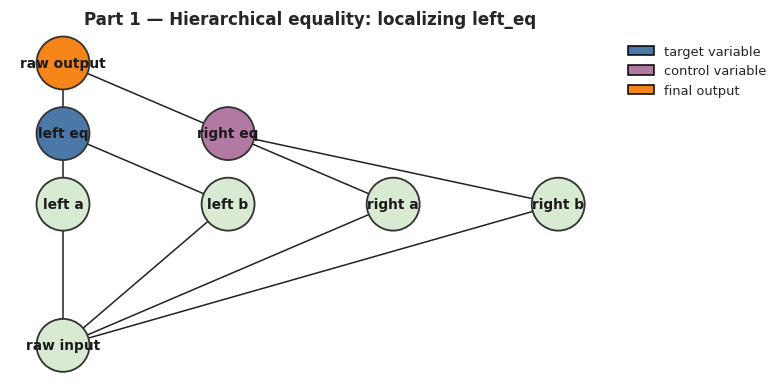

In [4]:
# Few-shot template with reasoning traces to help the model understand the task.
# The task: check if (left_a == left_b) has the same truth value as (right_a == right_b).
HIER_EQ_TEMPLATE = """Determine if the first two numbers are equal, and if the last two numbers are equal. Answer Yes if both comparisons have the same result, No otherwise.

5 5 8 8: First pair equal (5=5). Last pair equal (8=8). Both equal? Yes
Answer: Yes

2 3 4 4: First pair not equal (2!=3). Last pair equal (4=4). Both equal? No
Answer: No

9 9 6 7: First pair equal (9=9). Last pair not equal (6!=7). Both equal? No
Answer: No

1 2 3 4: First pair not equal (1!=2). Last pair not equal (3!=4). Both equal? Yes
Answer: Yes

{left_a} {left_b} {right_a} {right_b}:
Answer:"""


def make_hierarchical_equality_toy_model(*, n_values: int = 50) -> CausalModel:
    vals = list(range(n_values))

    values = {
        "left_a": vals,
        "left_b": vals,
        "right_a": vals,
        "right_b": vals,
        "left_eq": [False, True],
        "right_eq": [False, True],
        "raw_input": None,
        "raw_output": [" No", " Yes"],
    }

    mechanisms = {
        "left_a": input_var(vals),
        "left_b": input_var(vals),
        "right_a": input_var(vals),
        "right_b": input_var(vals),
        "left_eq": Mechanism(
            parents=["left_a", "left_b"],
            compute=lambda t: t["left_a"] == t["left_b"],
        ),
        "right_eq": Mechanism(
            parents=["right_a", "right_b"],
            compute=lambda t: t["right_a"] == t["right_b"],
        ),
        "raw_output": Mechanism(
            parents=["left_eq", "right_eq"],
            compute=lambda t: " Yes" if (t["left_eq"] == t["right_eq"]) else " No",
        ),
        "raw_input": Mechanism(
            parents=["left_a", "left_b", "right_a", "right_b"],
            compute=lambda t: HIER_EQ_TEMPLATE.format(
                left_a=t["left_a"], left_b=t["left_b"],
                right_a=t["right_a"], right_b=t["right_b"],
            ),
        ),
    }

    return CausalModel(mechanisms, values, id=f"hierarchical_equality_{n_values}")


hier_eq = make_hierarchical_equality_toy_model(n_values=50)

show_localization_view(
    hier_eq,
    target_vars=["left_eq"],
    control_vars=["right_eq"],
    title="Part 1 — Hierarchical equality: localizing left_eq",
)


### Step 1: Revisit the datasets at the causal-model level


Since the task itself is already familiar, the emphasis here is on the **counterfactual datasets**, not on relearning the task semantics. We keep one localization question in this section:

- target variable: `left_eq`
- competing variable: `right_eq`

For this question, we compare:

1. 🎲 a **random baseline**
2. 🎯 a **targeted dataset for $V$** (criteria 1+2)
3. 🟣 a **targeted dataset for $V$ against $W$** (criteria 1+2+3)

Dataset names:

- 🎯 **`left_eq_targeted`**: enforce variable-level change and non-trivial change in $Y$ for `left_eq`
- 🟣 **`left_eq_isolated`**: additionally require distinguishability from `right_eq`
- 🎲 **`random`**: resample leaves uniformly from input space

The code below reports three kinds of dataset-level evidence.

1. **Change-rate table:** how often does each causal variable change?
2. **Effect-rate table:** how often does intervening on that variable change the output of the high-level model?
3. **Localization scorecard:** how often does the dataset distinguish the target hypothesis from the competing hypothesis?

Part 1 — Hierarchical equality: change-rate table


,dataset,n,Δleft eq,Δright eq
0,left eq targeted,64,100.0%,54.7%
1,left eq isolated,64,100.0%,0.0%
2,random,64,54.7%,48.4%


Part 1 — Hierarchical equality: effect-rate table


,dataset,n,patch(left eq),patch(right eq)
0,left eq targeted,64,100.0%,54.7%
1,left eq isolated,64,100.0%,0.0%
2,random,64,54.7%,48.4%


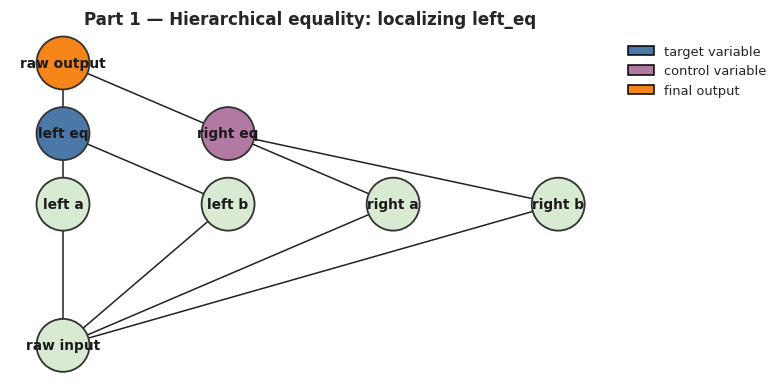

Part 1 — Hierarchical equality: scorecard for left_eq


,dataset,n,Δ target (left eq),patch(left eq) changes output,Δ control (right eq),patch(right eq) changes output,separates left eq vs right eq
0,left eq targeted,64,100.0%,100.0%,54.7%,54.7%,45.3%
1,left eq isolated,64,100.0%,100.0%,0.0%,0.0%,100.0%
2,random,64,54.7%,54.7%,48.4%,48.4%,43.8%


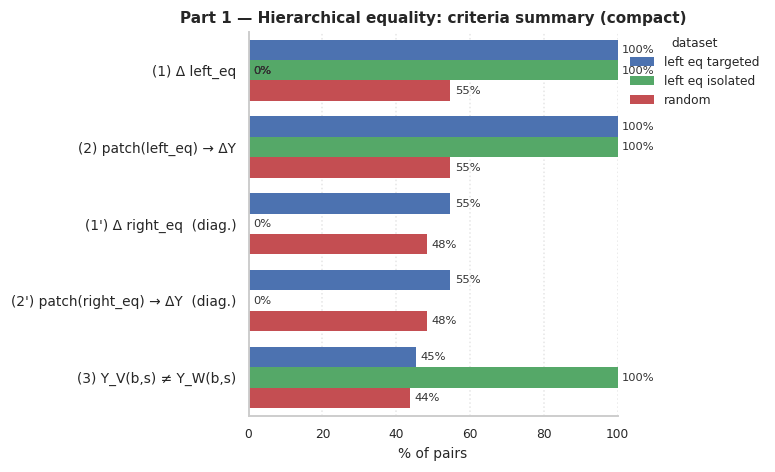

,dataset,n,Δ target (left_eq),patch(left_eq) changes output,Δ control (right_eq),patch(right_eq) changes output,separates left_eq vs right_eq
0,left_eq_targeted,64,100.0000,100.0000,54.6875,54.6875,45.3125
1,left_eq_isolated,64,100.0000,100.0000,0.0000,0.0000,100.0000
2,random,64,54.6875,54.6875,48.4375,48.4375,43.7500


In [5]:
def _sample_pair_with_target_eq(is_eq, *, n_values):
    """Sample two integers (a, b) such that (a == b) == is_eq."""
    a = random.randrange(n_values)
    if is_eq:
        return a, a
    b = random.randrange(n_values - 1)
    return a, (b + 1 if b >= a else b)


def _sample_hier_eq_with_eq(left_is_eq, right_is_eq, *, n_values=50):
    """Build a 4-leaf input whose left_eq / right_eq booleans are fixed."""
    la, lb = _sample_pair_with_target_eq(left_is_eq, n_values=n_values)
    ra, rb = _sample_pair_with_target_eq(right_is_eq, n_values=n_values)
    return {"left_a": la, "left_b": lb, "right_a": ra, "right_b": rb}


def hier_eq_random_pair(*, n_values=50):
    """Random baseline: independent (left_eq, right_eq) booleans for base and source."""
    base_l = random.choice([False, True])
    base_r = random.choice([False, True])
    cf_l = random.choice([False, True])
    cf_r = random.choice([False, True])
    base = _sample_hier_eq_with_eq(base_l, base_r, n_values=n_values)
    cf = _sample_hier_eq_with_eq(cf_l, cf_r, n_values=n_values)
    return {"input": hier_eq.new_trace(base), "counterfactual_inputs": [hier_eq.new_trace(cf)]}


def hier_eq_target_isolated_pair(*, target="left_eq"):
    """Isolated pair: flip the target equality, keep the competitor fixed."""
    base_l = random.choice([False, True])
    base_r = random.choice([False, True])
    if target == "left_eq":
        cf_l, cf_r = not base_l, base_r
    else:
        cf_l, cf_r = base_l, not base_r
    base = _sample_hier_eq_with_eq(base_l, base_r, n_values=50)
    cf = _sample_hier_eq_with_eq(cf_l, cf_r, n_values=50)
    return {"input": hier_eq.new_trace(base), "counterfactual_inputs": [hier_eq.new_trace(cf)]}


# Build the three datasets that Part 1 will compare.
N = 64 if _device == "cuda" else 16
hier_eq_datasets = {
    "left_eq_targeted": build_counterfactual_dataset(
        causal_model=hier_eq, sampler=hier_eq_random_pair, n=N,
        target="left_eq", other="right_eq",
        require_distinguishability=False, require_other_fixed=False,
    ),
    "left_eq_isolated": build_counterfactual_dataset(
        causal_model=hier_eq, sampler=hier_eq_target_isolated_pair, n=N,
        target="left_eq", other="right_eq",
        require_distinguishability=True, require_other_fixed=True,
    ),
    "random": make_dataset(N, hier_eq_random_pair),
}

target_var, competing_var = "left_eq", "right_eq"
display_change_rate_table(
    hier_eq_datasets, [target_var, competing_var],
    title="Part 1 — Hierarchical equality: change-rate table",
)
display_effect_rate_table(
    hier_eq, hier_eq_datasets,
    {f"patch({target_var})": [target_var], f"patch({competing_var})": [competing_var]},
    title="Part 1 — Hierarchical equality: effect-rate table",
)
show_localization_view(
    hier_eq, target_vars=[target_var], control_vars=[competing_var],
    title="Part 1 — Hierarchical equality: localizing left_eq",
)
display_localization_scorecard(
    hier_eq, hier_eq_datasets,
    target_vars=[target_var], control_vars=[competing_var],
    title="Part 1 — Hierarchical equality: scorecard for left_eq",
)
plot_dataset_criteria_bars(
    hier_eq, hier_eq_datasets,
    target_vars=[target_var], control_vars=[competing_var],
    title="Part 1 — Hierarchical equality: criteria summary (compact)",
)


### Step 2: Read `random`, `left_eq_targeted`, and `left_eq_isolated` pairs by hand


We inspect a few base/source pairs directly before any neural result. Hierarchical equality is familiar, so the aim here is not to relearn the task but to check on concrete traces that each dataset produces the causal contrast its role prescribes.

The localization question in this part takes target $V = \texttt{left\_eq}$ and alternative $W = \texttt{right\_eq}$. We print one pair from each of the three datasets:

- 🎲 one `random` pair,
- 🎯 one `left_eq_targeted` pair,
- 🟣 one `left_eq_isolated` pair.

Five questions to hold in mind when reading a pair:

1. Does `left_eq` (that is, $E_1$) change between $b$ and $s$?
2. Does `right_eq` (that is, $E_2$) change?
3. Does the `left_eq` test intervention yield a test counterfactual with output different from $Y_{\varnothing}(b)$, so that the pair induces a non-trivial change in $Y$ (criterion 2)?
4. Does `patch(left_eq)` produce a different output from `patch(right_eq)`, so that the pair separates the two localization hypotheses (criterion 3)?
5. Which localization claim does the pair bear on?

We also print one explicit confounding example drawn from `left_eq_targeted` and one explicit non-confounding example drawn from `left_eq_isolated`, showing the base/source traces alongside `patch(left_eq)` and `patch(right_eq)`.

In [6]:
print_one_pair_per_dataset(
    hier_eq_datasets,
    causal_model=hier_eq,
    variables=["left_eq", "right_eq"],
    target="left_eq", other="right_eq",
    title="Part 1 — Localizing left_eq: one pair from each dataset",
)

# Illustrate the confounding vs non-confounding distinction on concrete pairs.
# The first predicate asks for the pedagogical base=(True, False) source=(False, True)
# pattern; the second asks for base=(True, False) source=(False, False).
def _hier_matches_confounding(ex):
    b, c = ex["input"], ex["counterfactual_inputs"][0]
    return bool(b["left_eq"]) and not b["right_eq"] and not c["left_eq"] and bool(c["right_eq"])

def _hier_matches_nonconfounding(ex):
    b, c = ex["input"], ex["counterfactual_inputs"][0]
    return bool(b["left_eq"]) and not b["right_eq"] and not c["left_eq"] and not c["right_eq"]

print_confounding_and_nonconfounding(
    causal_model=hier_eq,
    variables=["left_eq", "right_eq"],
    target="left_eq", other="right_eq",
    confounding_source=hier_eq_datasets["left_eq_targeted"],
    nonconfounding_source=hier_eq_datasets["left_eq_isolated"],
    confounding_filter=_hier_matches_confounding,
    nonconfounding_filter=_hier_matches_nonconfounding,
    title="Part 1 — Confounding vs non-confounding (left_eq vs right_eq)",
)



=== Part 1 — Localizing left_eq: one pair from each dataset ===

--- left eq targeted dataset — one example pair ---
base input:
  Determine if the first two numbers are equal, and if the last two numbers are equal. Answer Yes if
  both comparisons have the same result, No otherwise.  5 5 8 8: First pair equal (5=5). Last pair
  equal (8=8). Both equal? Yes Answer: Yes  2 3 4 4: First pair not equal (2!=3). Last pair equal
  (4=4). Both equal? No Answer: No  9 9 6 7: First pair equal (9=9). Last pair not equal (6!=7).
  Both equal? No Answer: No  1 2 3 4: First pair not equal (1!=2). Last pair not equal (3!=4). Both
  equal? Yes Answer: Yes  32 32 31 31: Answer:
source input:
  Determine if the first two numbers are equal, and if the last two numbers are equal. Answer Yes if
  both comparisons have the same result, No otherwise.  5 5 8 8: First pair equal (5=5). Last pair
  equal (8=8). Both equal? Yes Answer: Yes  2 3 4 4: First pair not equal (2!=3). Last pair equal
  (4=4). Both eq

### Worked minimal example: confounding vs. non-confounding (hierarchical equality)

Target $V=\texttt{left\_eq}$, alternative $W=\texttt{right\_eq}$.

**Confounding pair.**  
Take base input $(I_1,I_2,I_3,I_4)=(7,7,2,5)$ and source input $(3,8,4,4)$.

On the base run, $V=\mathbf{T}$ and $W=\mathbf{F}$, so the output is $\mathrm{DIFF}$.  
On the source run, $V=\mathbf{F}$ and $W=\mathbf{T}$.

If we interchange $V$, the base output changes from $\mathrm{DIFF}$ to $\mathrm{SAME}$.  
If we interchange $W$, the base output also changes from $\mathrm{DIFF}$ to $\mathrm{SAME}$.

So $Y_V(b,s)=Y_W(b,s)$. This pair is **confounding**: it does not distinguish the hypothesis that a neural site realizes $V$ from the hypothesis that it realizes $W$.

**Non-confounding pair.**  
Keep the same base input, but use source input $(3,8,2,5)$.

On the source run, $V=\mathbf{F}$ and $W=\mathbf{F}$. So $V$ changes across base and source, but $W$ does not.

If we interchange $V$, the base output changes from $\mathrm{DIFF}$ to $\mathrm{SAME}$.  
If we interchange $W$, the output stays $\mathrm{DIFF}$.

So $Y_V(b,s)\neq Y_W(b,s)$. This pair is **non-confounding**: it separates the two localization hypotheses.

### Step 3: Residual-stream interchange interventions

We now move from the high-level model $\mathcal{H}_{\mathrm{HE}}$ to the low-level language model $\mathcal{L}$.

For each filtered base/source pair and each chosen layer-position site $h$, we:

1. run $\mathcal{L}$ on the base input,
2. run $\mathcal{L}$ on the source input, and
3. replace the base-run activation at $h$ with the corresponding source-run activation.


The quantity plotted in the heatmaps is **IIA**.



In [9]:
# Keep only examples the LM gets right on both base and source; then set up
# the intervention sites we will patch (one token per input leaf, plus the
# last token of the prompt).
_hier_filtered = filter_and_report(
    datasets=hier_eq_datasets, pipeline=pipeline, causal_model=hier_eq,
    metric=hier_metric, batch_size=FILTER_BATCH_SIZE, label="hier",
)

_hier_sites = build_hier_token_positions(pipeline, prompt_template=HIER_EQ_TEMPLATE)
_hier_token_positions = _hier_sites["positions"]
_hier_pos_id_to_label = _hier_sites["label_map"]
_layers_hier = default_layers(pipeline, _device)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[hier] Filtering datasets (keep only examples the LM gets right)...
  left_eq_targeted: kept 26/64 examples
  left_eq_isolated: kept 11/64 examples
  random: kept 22/64 examples


In [ ]:
results_hier, targets_hier = run_patching_for_datasets(
    pipeline=pipeline,
    causal_model=hier_eq,
    datasets=_hier_filtered,
    token_positions=_hier_token_positions,
    target_variable_groups=[("left_eq",)],
    metric=hier_metric,
    batch_size=PATCH_BATCH_SIZE,
    layers=_layers_hier,
)

print("\nInterventions complete and scores computed.")


### Step 4: Read the heatmaps

**Target and alternative.** The target variable is $V = \texttt{left\_eq}$, the internal equality $E_1$. The alternative is $W = \texttt{right\_eq}$, the internal equality $E_2$. The question is where in the language model $V$ is realized.

**Panel layout.** Each comparison renders three heatmaps side by side:

1. absolute IIA on the comparison dataset (`left_eq_targeted` or `random`),
2. absolute IIA on `left_eq_isolated`,
3. the difference panel, $\Delta\mathrm{IIA} = \text{IIA}_{\texttt{left\_eq\_isolated}} - \text{IIA}_{\text{comparison}}$.

Rows correspond to transformer layers, top to last and bottom to input. Columns correspond to intervention token positions. Cell annotations give the IIA or $\Delta\mathrm{IIA}$ value, with boldface indicating $|\text{IIA}| > 0.5$.

**Reading conventions.** In the absolute panels, darker purple indicates higher IIA. In the $\Delta\mathrm{IIA}$ panel, red indicates that `left_eq_isolated` scores higher than the comparison, and blue the reverse.

**Two comparisons.** The main comparison is `left_eq_isolated` against `left_eq_targeted`. Both datasets enforce (1) and (2). Only `left_eq_isolated` additionally enforces (3), namely $Y_{\texttt{left\_eq}}(b, s) \neq Y_{\texttt{right\_eq}}(b, s)$. A site whose IIA drops when the dataset moves from `left_eq_targeted` to `left_eq_isolated` is a site whose earlier signal was confounded with `right_eq`. The secondary comparison is `left_eq_isolated` against `random`. Random pairs change multiple variables together and typically yield diffuse IIA. The comparison checks only that the designed contrast concentrates signal that a random contrast does not.


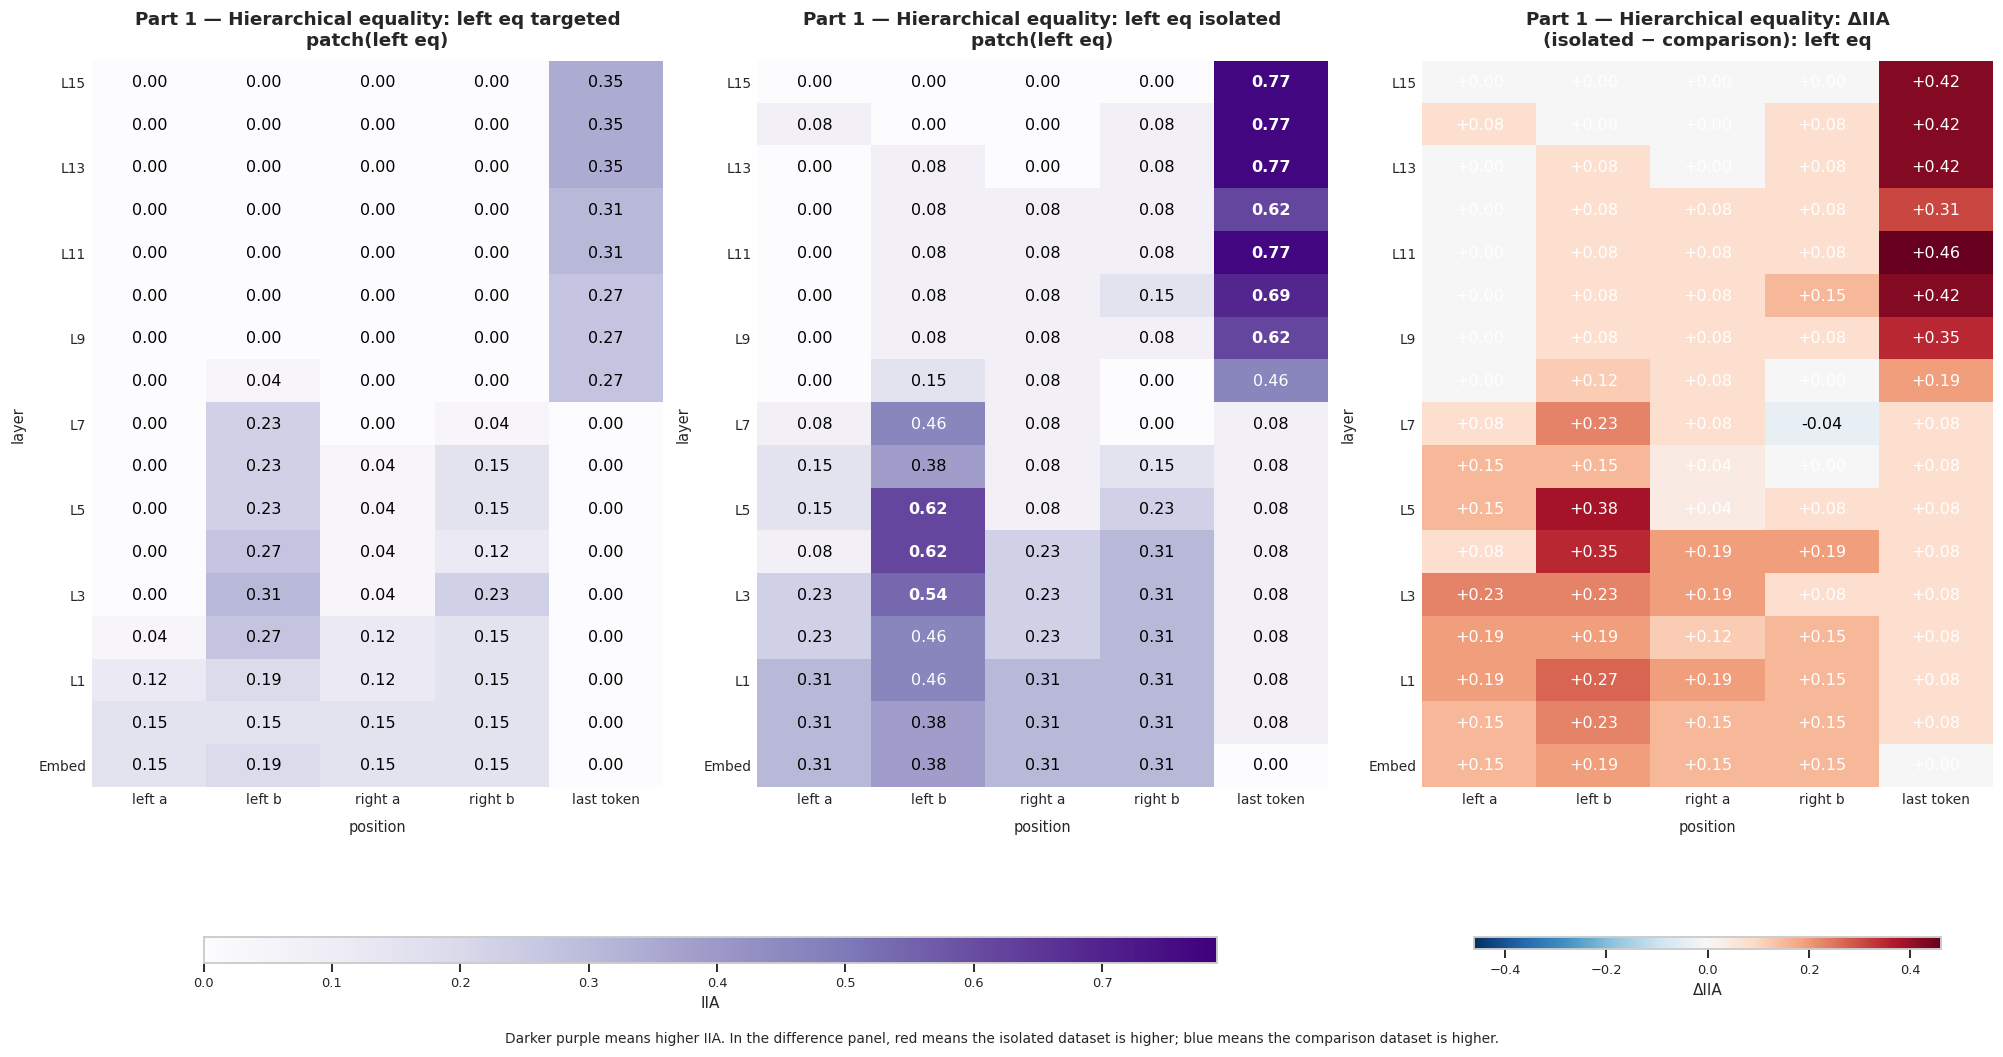

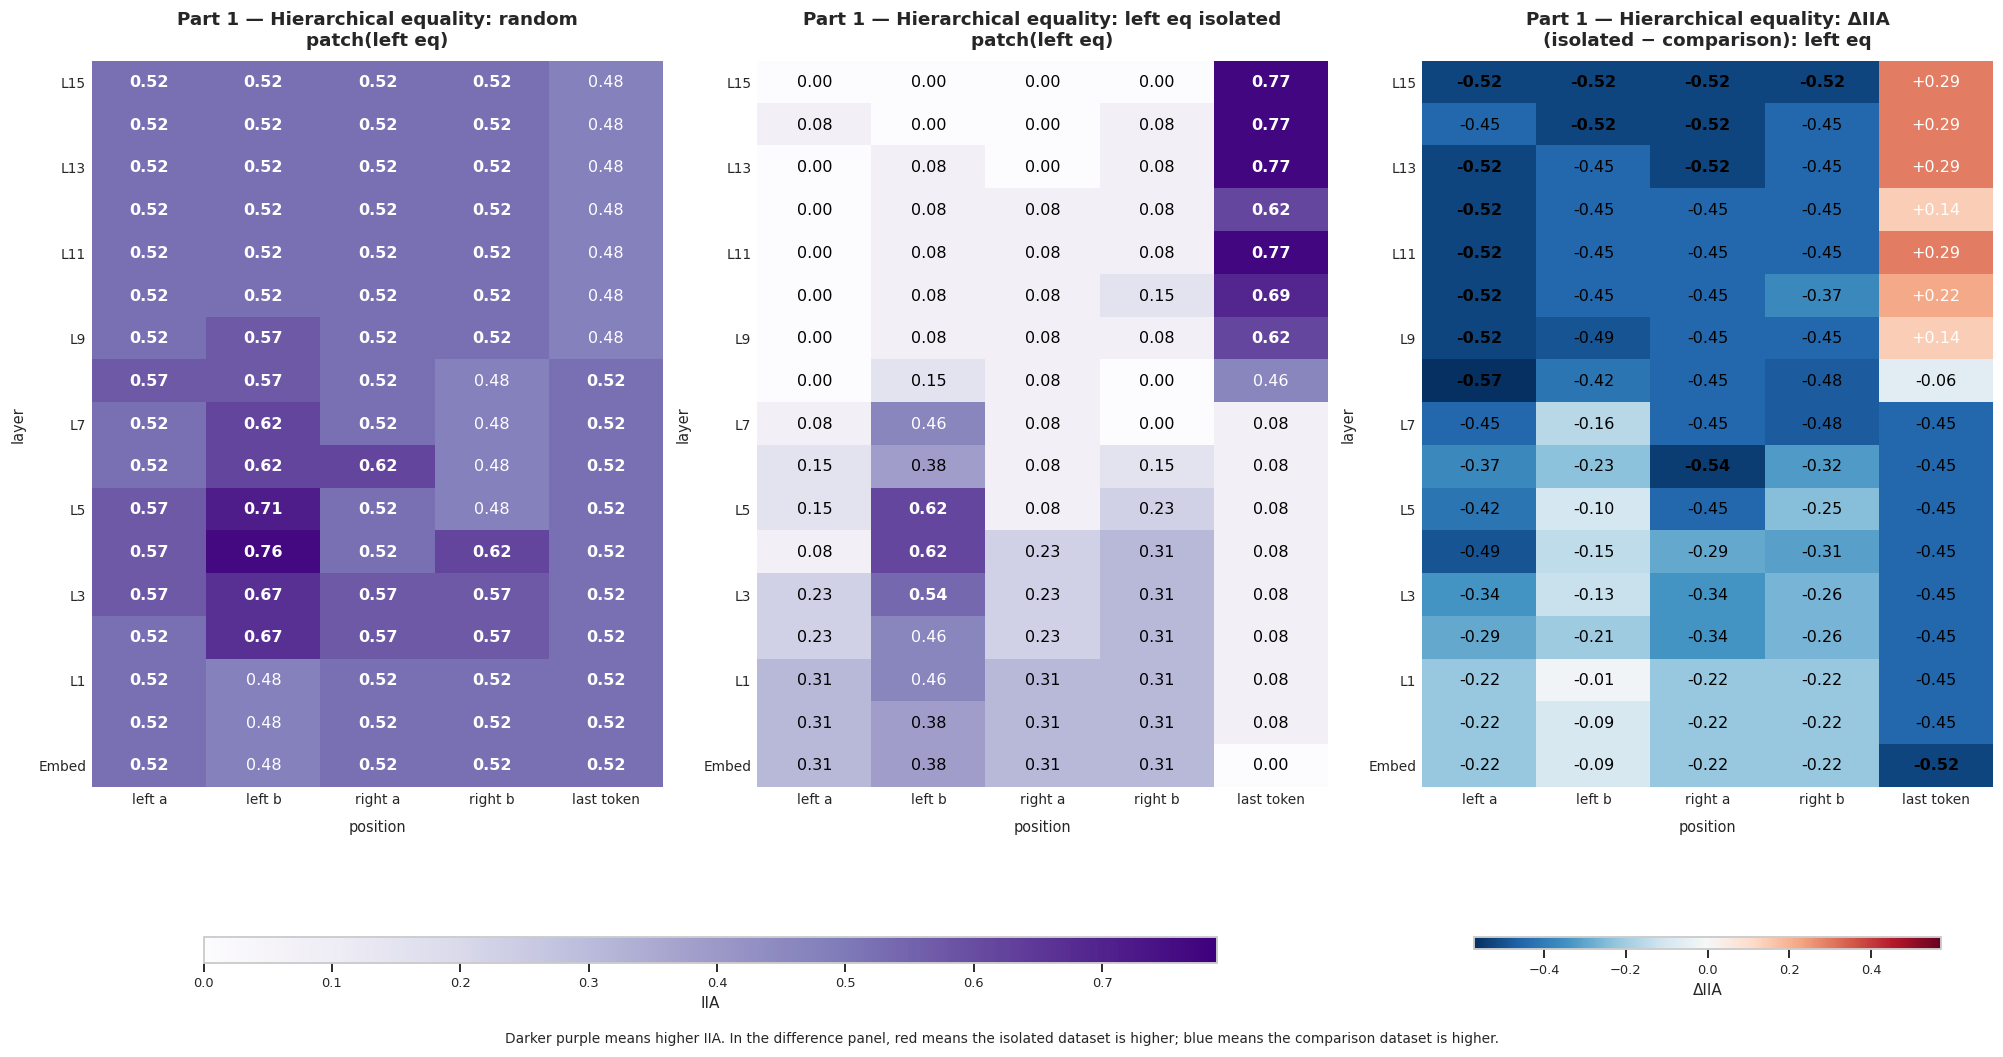

In [9]:
plot_iia_target_control_random(
    results=results_hier,
    targets=targets_hier,
    var_name="left_eq",
    dataset_targeted="left_eq_isolated",
    dataset_control="left_eq_targeted",
    dataset_random="random",
    pos_id_to_label=_hier_pos_id_to_label,
    title_prefix="Part 1 — Hierarchical equality: ",
)

In [10]:
print("Part 1 keeps a single localization target (left_eq), so no second heatmap is plotted.")

Part 1 keeps a single localization target (left_eq), so no second heatmap is plotted.


## 2️⃣ Part 2 — MCQA

We now keep the same workflow but move to a task that comes directly from the pinned codebase.

### 🎯 The task

This MCQA task is a **controlled multiple-choice question answering task**, not a general-knowledge benchmark. A prompt states an object and its color, presents two answer choices, associates each choice with a response symbol, and asks the model to output the correct symbol.

The high-level model $\mathcal{H}_{\mathrm{MCQA}}$ contains variables such as:

- `object`
- `color`
- `choice0`, `choice1`
- `symbol0`, `symbol1`

From these, the task code computes two central variables:

$$
P
\;:=\;
\texttt{answer\_position},
\qquad
A
\;:=\;
\texttt{answer}.
$$

Here `answer_position` records **which choice index** contains the correct color, whereas `answer` records **which response symbol** should be emitted.

### 🔬 Localization hypotheses

We study a single localization question, instantiated as in the global table:

- **Target $V = P \leftrightarrow$ `answer_position`.** $H_V$ is the hypothesis that some hidden-state site in $\mathcal{L}$ plays the causal role of `answer_position`, the index of the correct option among A/B/C/D.
- **Alternative $W = A \leftrightarrow$ `answer`.** $W$ is the competing variable against which the dataset must distinguish $V$. The two variables both feed into the final answer but through different causal roles, which is exactly why criterion (3) is needed: a high IIA on a candidate site is taken as evidence for $H_V$ only when the dataset has shown, at the causal-model level, that interchanging $V$ and interchanging $W$ produce different outputs.


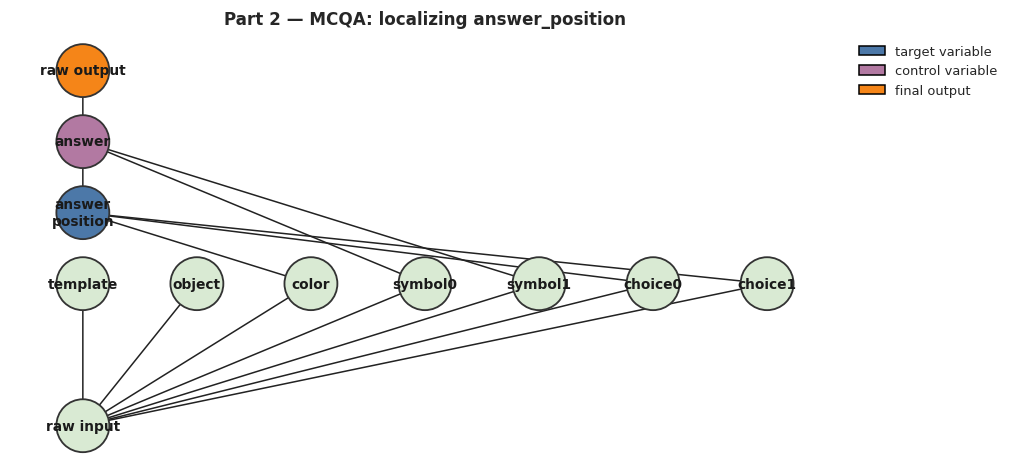

Example prompt from the task code:

The house is pink. What color is the house?
G. white
M. pink
Answer:

Base output: M
Base answer_position: 1
Base answer symbol: M


In [11]:
from causalab.tasks.MCQA.causal_models import positional_causal_model
from causalab.tasks.MCQA.counterfactuals import (
    different_symbol,
    random_counterfactual,
    same_symbol_different_position,
    sample_answerable_question,
)

show_localization_view(
    positional_causal_model,
    target_vars=["answer_position"],
    control_vars=["answer"],
    title="Part 2 — MCQA: localizing answer_position",
)
example = sample_answerable_question()
print("Example prompt from the task code:\n")
print(example["raw_input"])
print("\nBase output:", example["raw_output"].strip())
print("Base answer_position:", example["answer_position"])
print("Base answer symbol:", example["answer"])


### 🔬 Step 1: Build the MCQA datasets and verify what they change

Part 2 reuses the same three dataset roles as Part 1 for a single localization question. The target variable is $V = \texttt{answer\_position}$, the index of the correct option among A/B/C/D. The alternative variable is $W = \texttt{answer}$, the answer string itself.

Dataset roles:

- 🎲 `random` draws samples from the input space without enforcing a causal contrast.
- 🎯 `answer_position_targeted` enforces (1) variable-level change for `answer_position` together with (2) non-trivial change in $Y$ of `patch(answer_position)`.
- 🟣 `answer_position_isolated` additionally enforces (3): `patch(answer_position)` and `patch(answer)` produce different causal-model outputs.

We draw candidates from the task-code generators. `random_counterfactual` supplies candidates for `random` and `answer_position_targeted`. `same_symbol_different_position` supplies candidates for `answer_position_isolated`, swapping the position of the correct option while holding the answer string fixed.

As in Part 1, three dataset-level checks run before any neural experiment:

1. **Change-rate table.** Rates such as $\mathbb{P}[\Delta_P]$ and $\mathbb{P}[\Delta_A]$ over the dataset, where $P$ abbreviates `answer_position` and $A$ abbreviates `answer`.
2. **Effect-rate table.** The rate at which intervening on `answer_position` or on `answer` changes the output of $\mathcal{H}_{\mathrm{MCQA}}$.
3. **Localization scorecard.** The rate at which a dataset distinguishes $H_V$ (the hypothesis that the site realizes `answer_position`) from $H_W$ (the hypothesis that the site realizes `answer`).


Part 2 — MCQA: change-rate table


,dataset,n,Δanswer position,Δanswer
0,answer position targeted,64,100.0%,96.9%
1,answer position isolated,64,100.0%,0.0%
2,random,64,40.6%,95.3%


Part 2 — MCQA: effect-rate table


,dataset,n,patch(answer position),patch(answer)
0,answer position targeted,64,100.0%,96.9%
1,answer position isolated,64,100.0%,0.0%
2,random,64,40.6%,95.3%


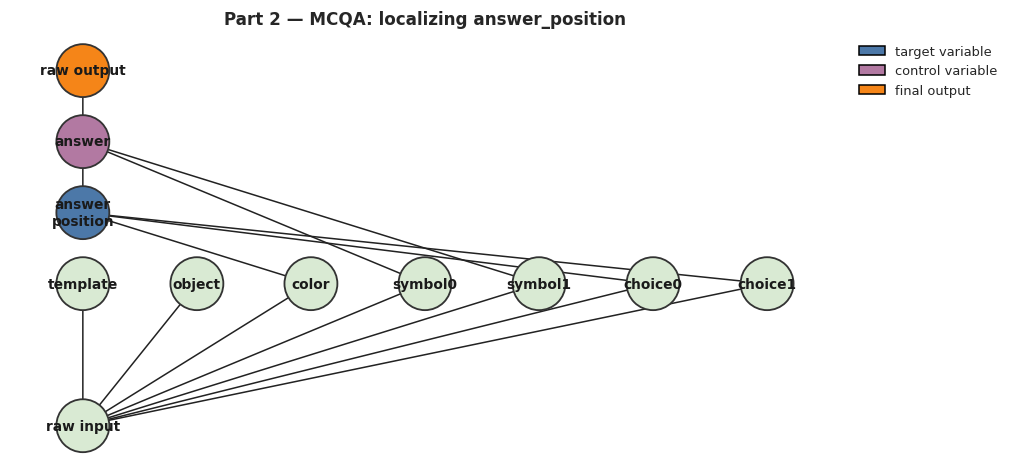

Part 2 — MCQA: scorecard for answer_position


,dataset,n,Δ target (answer position),patch(answer position) changes output,Δ control (answer),patch(answer) changes output,separates answer position vs answer
0,answer position targeted,64,100.0%,100.0%,96.9%,96.9%,93.8%
1,answer position isolated,64,100.0%,100.0%,0.0%,0.0%,100.0%
2,random,64,40.6%,40.6%,95.3%,95.3%,98.4%


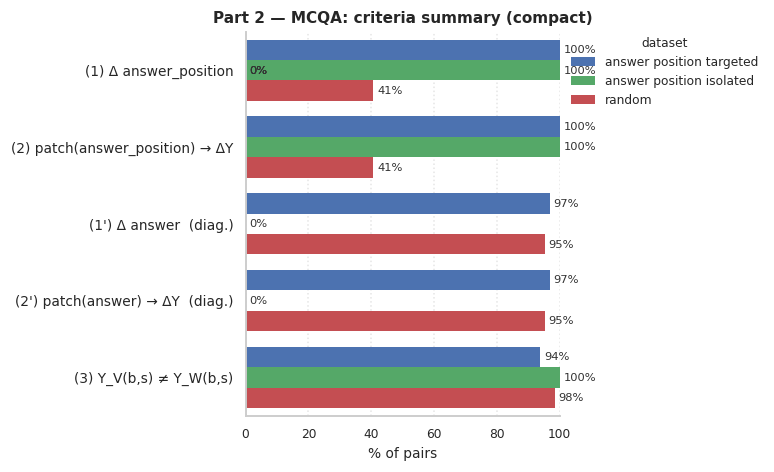

,dataset,n,Δ target (answer_position),patch(answer_position) changes output,Δ control (answer),patch(answer) changes output,separates answer_position vs answer
0,answer_position_targeted,64,100.000,100.000,96.8750,96.8750,93.7500
1,answer_position_isolated,64,100.000,100.000,0.0000,0.0000,100.0000
2,random,64,40.625,40.625,95.3125,95.3125,98.4375


In [12]:
N_MCQA = 64
mcqa_datasets_diag = {
    "answer_position_targeted": build_counterfactual_dataset(
        causal_model=positional_causal_model, sampler=random_counterfactual, n=N_MCQA,
        target="answer_position", other="answer",
        require_distinguishability=False, require_other_fixed=False,
    ),
    "answer_position_isolated": build_counterfactual_dataset(
        causal_model=positional_causal_model, sampler=same_symbol_different_position, n=N_MCQA,
        target="answer_position", other="answer",
        require_distinguishability=True, require_other_fixed=True,
    ),
    "random": make_dataset(N_MCQA, random_counterfactual),
}

target, control = "answer_position", "answer"
display_change_rate_table(
    mcqa_datasets_diag, [target, control],
    title="Part 2 — MCQA: change-rate table",
)
display_effect_rate_table(
    positional_causal_model, mcqa_datasets_diag,
    {f"patch({target})": [target], f"patch({control})": [control]},
    title="Part 2 — MCQA: effect-rate table",
)
show_localization_view(
    positional_causal_model, target_vars=[target], control_vars=[control],
    title="Part 2 — MCQA: localizing answer_position",
)
display_localization_scorecard(
    positional_causal_model, mcqa_datasets_diag,
    target_vars=[target], control_vars=[control],
    title="Part 2 — MCQA: scorecard for answer_position",
)
plot_dataset_criteria_bars(
    positional_causal_model, mcqa_datasets_diag,
    target_vars=[target], control_vars=[control],
    title="Part 2 — MCQA: criteria summary (compact)",
)


### 👀 Step 2: Read `random`, `answer_position_targeted`, and `answer_position_isolated` pairs by hand

We inspect concrete traces before scaling up, as in Part 1. With target $V = \texttt{answer\_position}$ and alternative $W = \texttt{answer}$, we print one pair from each dataset:

- 🎲 one `random` pair,
- 🎯 one `answer_position_targeted` pair,
- 🟣 one `answer_position_isolated` pair.

Five questions to hold in mind when reading a pair:

1. Does `answer_position` change between $b$ and $s$?
2. Does `answer` change?
3. Does the `answer_position` test intervention yield a test counterfactual with output different from $Y_{\varnothing}(b)$ (criterion 2)?
4. Does `patch(answer_position)` produce a different output from `patch(answer)` (criterion 3)?
5. Which localization hypothesis does the pair bear on?

We also print one confounding example drawn from `answer_position_targeted` and one non-confounding example drawn from `answer_position_isolated`, following the Part 1 convention.


In [13]:
print_one_pair_per_dataset(
    mcqa_datasets_diag,
    causal_model=positional_causal_model,
    variables=["answer_position", "answer"],
    target="answer_position", other="answer",
    title="Part 2 — Localizing answer_position: one pair from each dataset",
)

print_confounding_and_nonconfounding(
    causal_model=positional_causal_model,
    variables=["answer_position", "answer"],
    target="answer_position", other="answer",
    confounding_source=mcqa_datasets_diag["answer_position_targeted"],
    nonconfounding_source=mcqa_datasets_diag["answer_position_isolated"],
    title="Part 2 — Confounding vs non-confounding (answer_position vs answer)",
)



=== Part 2 — Localizing answer_position: one pair from each dataset ===

--- answer position targeted dataset — one example pair ---
base input:
  The car is green. What color is the car? C. green A. blue Answer:
source input:
  The cup is brown. What color is the cup? L. purple V. brown Answer:
variable values:
  - answer_position: base=0 | source=1 | CHANGED
  - answer: base=C | source=V | CHANGED
outputs:
  base output:   C
  source output: V
  patch(answer_position) -> A
  patch(answer)  -> V

--- answer position isolated dataset — one example pair ---
base input:
  The shoe is yellow. What color is the shoe? D. black E. yellow Answer:
source input:
  The shoe is yellow. What color is the shoe? E. yellow D. black Answer:
variable values:
  - answer_position: base=1 | source=0 | CHANGED
  - answer: base=E | source=E | same
outputs:
  base output:   E
  source output: E
  patch(answer_position) -> D
  patch(answer)  -> E

--- random dataset — one example pair ---
base input:
  The c

### 🧩 Worked minimal example: confounding vs non-confounding (MCQA)

Let $V=\texttt{answer\_position}$, the position of the correct option in the list, and let $W=\texttt{answer}$, the letter of the correct option.

**Confounding pair.**  
Take the base example

> The ball is red. What color is the ball?  
> A. red  
> B. blue  
> Answer:

Here the correct answer is in the first position, so $\texttt{answer\_position}=0$, and its letter is $\texttt{answer}=\mathtt{A}$.

Now take the source example

> The ball is red. What color is the ball?  
> A. blue  
> B. red  
> Answer:

Here the correct answer is in the second position, so $\texttt{answer\_position}=1$, and its letter is $\texttt{answer}=\mathtt{B}$.

This pair is **confounding** because both variables change. If we interchange on $V$, the base is pushed toward position $1$, whose letter in the base is $\mathtt{B}$. If we interchange on $W$, the base is pushed directly toward $\mathtt{B}$. So both interventions predict the same output: $Y_V(b,s)=Y_W(b,s)=\mathtt{B}$. This pair does not distinguish the two localization hypotheses.

**Non-confounding pair.**  
Keep the correct letter fixed, but move it to a different position. For example, take the source

> The ball is blue. What color is the ball?  
> B. red  
> A. blue  
> Answer:

Here the correct option is in the second position, so $\texttt{answer\_position}=1$, but the correct letter is still $\texttt{answer}=\mathtt{A}$.

This pair is **non-confounding** for $V$ against $W$. The position changes, so $\Delta_V=1$, but the letter does not, so $\Delta_W=0$. If we interchange on $V$, the base is pushed toward position $1$, whose letter in the base is $\mathtt{B}$, so $Y_V(b,s)=\mathtt{B}$. If we interchange on $W$, the letter stays $\mathtt{A}$, so $Y_W(b,s)=\mathtt{A}$. Since $Y_V(b,s)\neq Y_W(b,s)$, the pair separates the two hypotheses.

### 🧠 Step 3: Patch the language model on filtered MCQA examples

We run the same residual-stream interchange experiment as in Part 1. Filtering retains only the examples on which the language model and the causal model agree on the ordinary task behavior. Patching then iterates over the token positions supplied by the task code, intervening at each layer-position site in turn.

The localization question takes target $V = \texttt{answer\_position}$ and alternative $W = \texttt{answer}$. We evaluate two comparisons.

- 🟣 `answer_position_isolated` against 🎯 `answer_position_targeted`, the main comparison.
- 🟣 `answer_position_isolated` against 🎲 `random`, a secondary comparison.

The first bears most directly on the localization claim. It asks whether enforcing criterion (3) sharpens the low-level signal for `answer_position` beyond what criteria (1) and (2) already deliver.


In [14]:
size = 32 if _device == "cuda" else 16
mcqa_counterfactual_datasets = {
    "answer_position_targeted": mcqa_datasets_diag["answer_position_targeted"][:size],
    "answer_position_isolated": mcqa_datasets_diag["answer_position_isolated"][:size],
    "random": mcqa_datasets_diag["random"][: max(size, min(len(mcqa_datasets_diag["random"]), 2 * size))],
}

mcqa_filtered = filter_and_report(
    datasets=mcqa_counterfactual_datasets,
    pipeline=pipeline, causal_model=positional_causal_model,
    metric=mcqa_metric, batch_size=FILTER_BATCH_SIZE, label="mcqa",
    min_kept_warn=8,
)

# We patch at each choice-symbol token (e.g. the "A" / "B" letters), at the
# period that terminates each choice, and at the last token of the prompt.
_mcqa_sites = build_mcqa_token_positions(pipeline)
token_positions_mcqa = _mcqa_sites["positions"]
mcqa_pos_id_to_label = _mcqa_sites["label_map"]
layers_mcqa = default_layers(pipeline, _device)


[mcqa] Filtering datasets (keep only examples the LM gets right)...


Computing base outputs:   0%|          | 0/1 [00:00<?, ?it/s]

  answer_position_targeted: kept 27/32 examples


  answer_position_isolated: kept 28/32 examples


  random: kept 54/64 examples


In [15]:
results_mcqa, targets_mcqa = run_patching_for_datasets(
    pipeline=pipeline,
    causal_model=positional_causal_model,
    datasets=mcqa_filtered,
    token_positions=token_positions_mcqa,
    target_variable_groups=[("answer_position",)],
    metric=mcqa_metric,
    batch_size=PATCH_BATCH_SIZE,
    layers=layers_mcqa,
)
print("\nInterventions complete and scores computed.")



Running patching on 'answer_position_targeted' (27 examples)


Running interventions:   0%|          | 0/119 [00:00<?, ?it/s]

Running interventions: 100%|██████████| 119/119 [02:44<00:00,  1.39s/it]



Running patching on 'answer_position_isolated' (28 examples)


Running interventions: 100%|██████████| 119/119 [02:50<00:00,  1.43s/it]



Running patching on 'random' (54 examples)


Running interventions: 100%|██████████| 119/119 [04:51<00:00,  2.45s/it]


Interventions complete and scores computed.


### 📈 Step 4: Read the MCQA heatmaps

**Target and alternative.** The target is $V = \texttt{answer\_position}$, the index of the correct choice among A/B/C/D. The alternative is $W = \texttt{answer}$, the answer string. The localization question concerns where in the language model `answer_position` is realized, as distinct from the content of the answer.

**Panel layout.** Each comparison renders three heatmaps:

1. absolute IIA on the comparison dataset (`answer_position_targeted` or `random`),
2. absolute IIA on `answer_position_isolated`,
3. $\Delta\mathrm{IIA} = \text{IIA}_{\texttt{answer\_position\_isolated}} - \text{IIA}_{\text{comparison}}$.

**Two comparisons.** The main comparison is `answer_position_isolated` against `answer_position_targeted`. Both datasets change `answer_position`. Only `answer_position_isolated` additionally imposes $Y_{\texttt{answer\_position}}(b, s) \neq Y_{\texttt{answer}}(b, s)$, so the comparison probes whether enforcing (3) sharpens the signal for position as distinct from content. The secondary comparison is `answer_position_isolated` against `random`, a check that the designed dataset concentrates structure that unconstrained pairs do not.

A neural pattern merits interpretation only when the causal-model diagnostics already hold. Specifically, `answer_position` should change at a high rate (criterion 1), `patch(answer_position)` should be non-trivial (criterion 2), and $Y_{\texttt{answer\_position}} \neq Y_{\texttt{answer}}$ should hold at the high level (criterion 3). The criteria bar chart shown earlier is the fastest way to verify these.


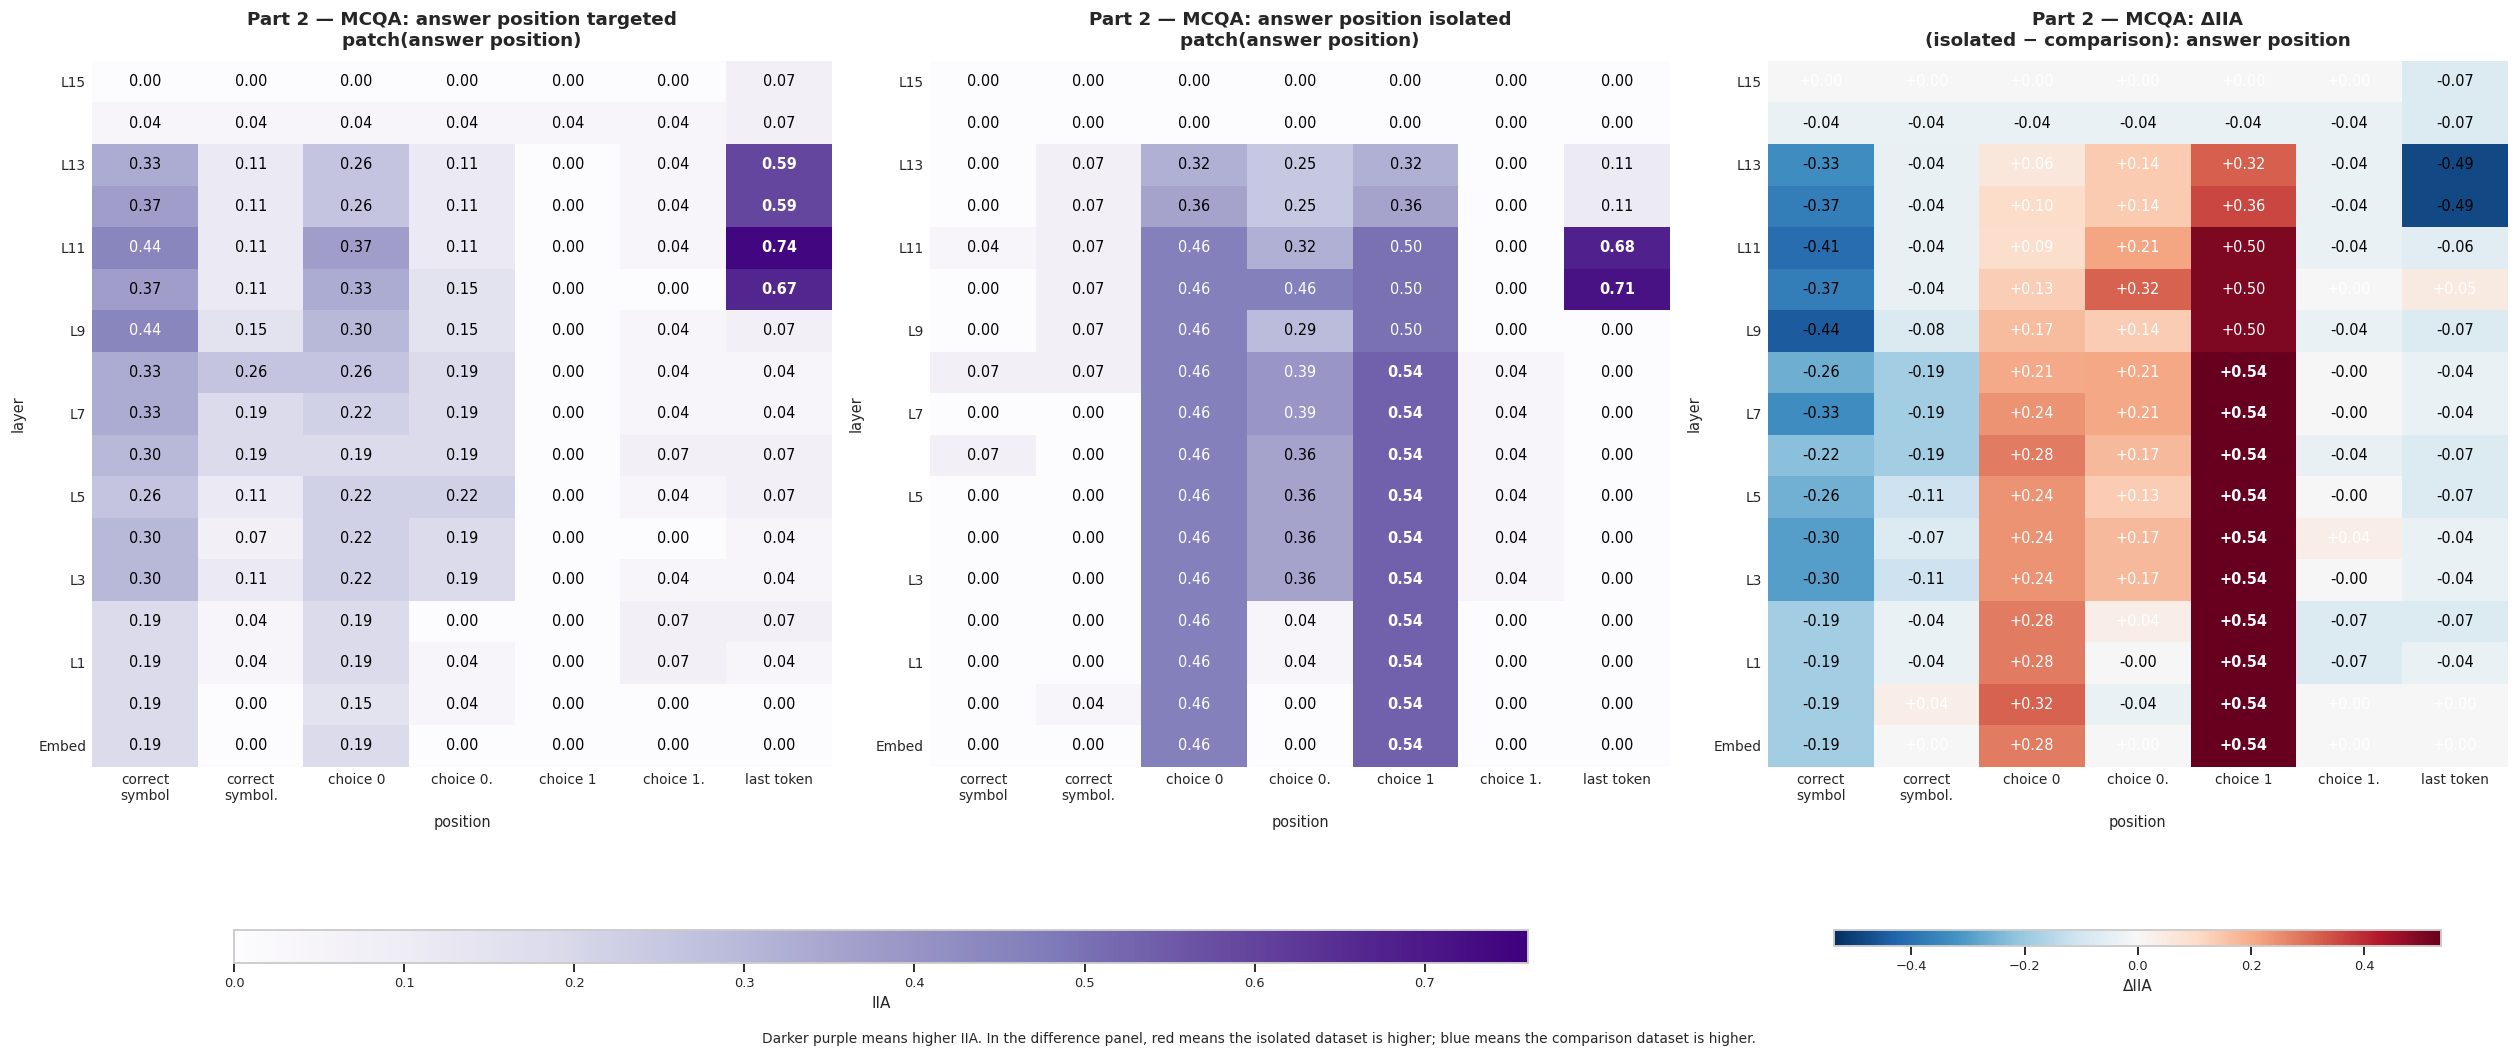

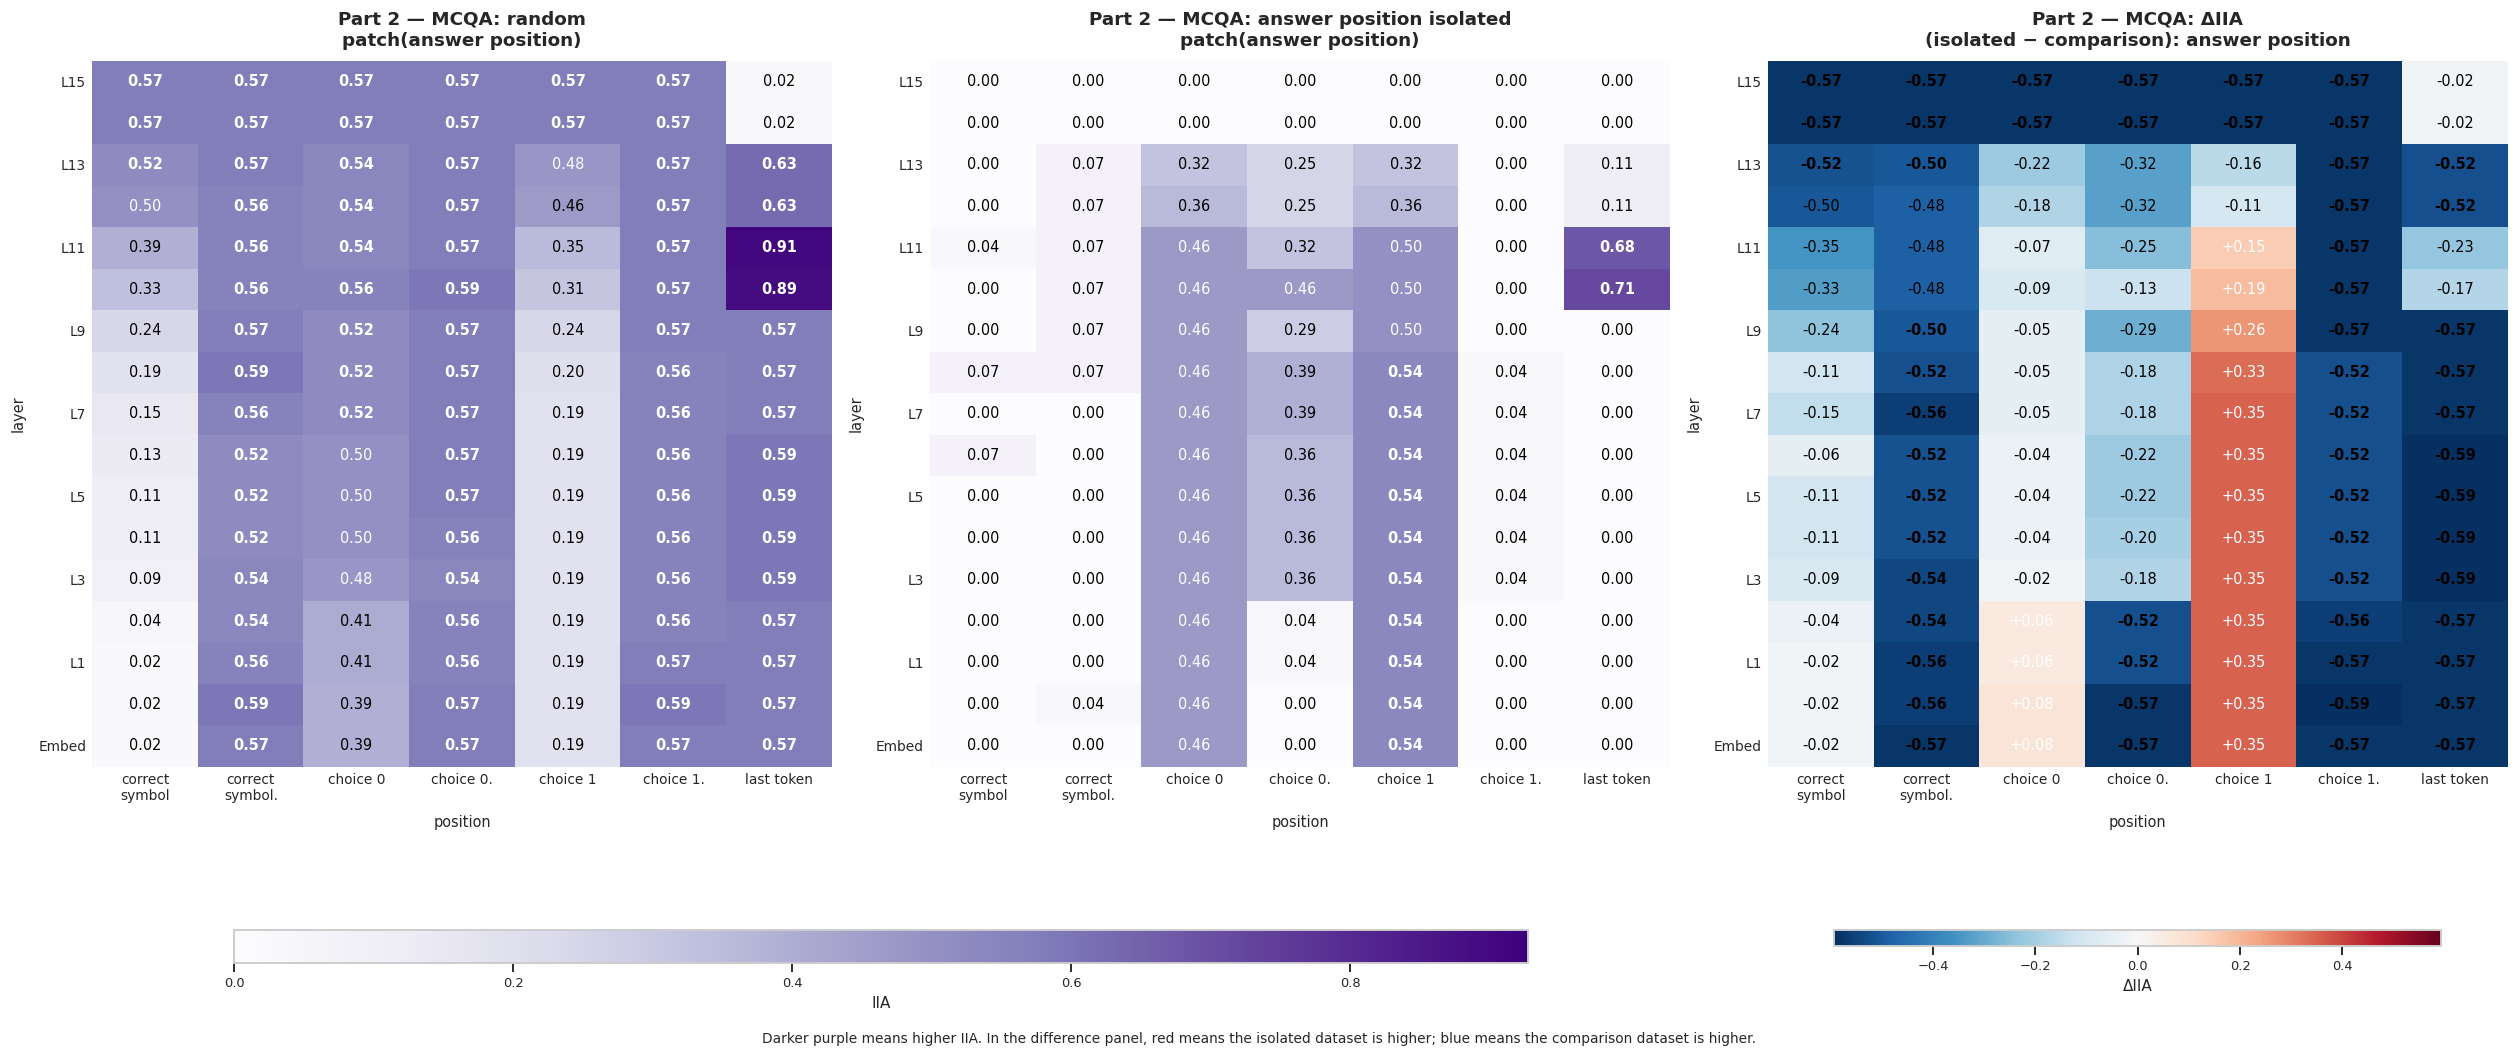

In [16]:
plot_iia_target_control_random(
    results=results_mcqa,
    targets=targets_mcqa,
    var_name="answer_position",
    dataset_targeted="answer_position_isolated",
    dataset_control="answer_position_targeted",
    dataset_random="random",
    pos_id_to_label=mcqa_pos_id_to_label,
    title_prefix="Part 2 — MCQA: ",
)

In [17]:
print("Part 2 keeps a single localization target (answer_position), so no second heatmap is plotted.")

Part 2 keeps a single localization target (answer_position), so no second heatmap is plotted.


## 3️⃣ Part 3 — Entity binding


### 🎯 The task

The prompt contains short factual statements that bind entities together — for example, a person with an associated object — followed by a question that asks the model to retrieve the corresponding bound entity.

This is a small instance of **binding and retrieval**: given a query, recover the entity that is causally linked to it in context.

### 🔬 Candidate high-level models in the attached codebase

The attached codebase includes an older `entity_binding` task with **two** candidate causal models.

- **Direct model**: retrieve the answer by using `query_group` directly as the address.
- **Search model**: first recover `query_entity`, then recover `positional_query_group`, and then retrieve the answer from that group.

These two models often agree on ordinary inputs, so a single prompt is usually not enough to distinguish them. The counterfactual-design problem is therefore more delicate: we need pairs that separate the relevant internal variables and, when possible, separate the competing causal stories.

In the localization part of this notebook, we focus on two variables inside the search-style story:

$$
Q
\;:=\;
\texttt{query\_entity},
\qquad
G
\;:=\;
\texttt{positional\_query\_group}.
$$

We study a single localization question, instantiated as in the global table:

- **Target $V = Q \leftrightarrow$ `query_entity`.** $H_V$ is the hypothesis that some hidden-state site in $\mathcal{L}$ plays the causal role of `query_entity`, the entity named in the question.
- **Alternative $W = G \leftrightarrow$ `positional_query_group`.** $W$ is the competing variable against which the dataset must distinguish $V$. In ordinary inputs the search model recovers the answer by first identifying $V$ and then reading $G$, so prompts very often pin down $V$ and $G$ jointly. Criterion (3) is therefore the binding constraint here: a high IIA on a candidate site is taken as evidence for $H_V$ only when the dataset has shown, at the causal-model level, that interchanging $V$ and interchanging $W$ produce different outputs.


In [18]:
from causalab.tasks.entity_binding.config import create_sample_love_config
from causalab.tasks.entity_binding.causal_models import (
    create_direct_causal_model,
    create_positional_causal_model,
)

install_entity_binding_shims()

random.seed(0)
np.random.seed(0)

# Two-group "love" prompt: each group contains two entities (person, object),
# and the question asks "What does <person> love?".
config = create_sample_love_config()
config.max_groups = 2
config.prompt_prefix = "We will ask a question about the following sentences.\n\n"
config.statement_question_separator = "\n\n"
config.prompt_suffix = "\nAnswer:"
config.fixed_query_indices = (0,)

direct_model = create_direct_causal_model(config)
positional_model = create_positional_causal_model(config)

print("Created the two causal models used in the entity-binding walkthroughs:")
print(f"  direct model:     {direct_model.id}")
print(f"  positional model: {positional_model.id}")

# Part 3 uses GPT-2 so the structured token-position parser can resolve the
# intervention sites reliably on the "love" prompt format.
pipeline_eb = load_entity_binding_pipeline(device=_device)


Created the two causal models used in the entity-binding walkthroughs:
  direct model:     entity_binding_direct_2g_2e
  positional model: entity_binding_positional_2g_2e
Entity-binding pipeline: gpt2 | device: cuda


### 🔍 Step 1 — Compare the task-code causal models on one concrete input

We start with a hand-built example and run both task-code causal models on it.

This does three things.

1. It fixes the task semantics in a concrete prompt.
2. It makes the intermediate variables visible.
3. It shows why ordinary inputs do not by themselves decide between the two causal stories.

A single example is therefore **descriptive**, not **discriminative**. Its role is to map the prompt onto the variable names used in the code and to prepare for the counterfactual-design problem that follows.


In [19]:
# One concrete input we will run through both causal models.
input_sample = {
    "entity_g0_e0": "Pete",
    "entity_g0_e1": "jam",
    "entity_g1_e0": "Ann",
    "entity_g1_e1": "pie",
    "query_group": 1,
    "query_indices": (0,),
    "answer_index": 1,
    "active_groups": config.max_groups,
    "entities_per_group": 2,
    "statement_template": config.statement_template,
}

print("\nInput configuration:")
print("  Entities: g0=(Pete, jam), g1=(Ann, pie)")
print(f"  Query: group {input_sample['query_group']}, entity {input_sample['query_indices'][0]}")
print(f"  Answer: entity at group {input_sample['query_group']}, position {input_sample['answer_index']}")

_direct_out = direct_model.new_trace(input_sample)
_positional_out = positional_model.new_trace(input_sample)

print("\nPrompt generated:")
print(f"  {_direct_out['raw_input']}")
print()

print("Direct model (lookup by query_group):")
print(f"  Mechanism: uses query_group={input_sample['query_group']} directly")
print(f"  Answer: {_direct_out['raw_output']}")
print()

print("Positional model (task-code name):")
print(f"  query_entity: {_positional_out['query_entity']}")
print(f"  positional_query_group: {_positional_out['positional_query_group']}")
print(f"  Answer: {_positional_out['raw_output']}")
print()

print("Do the two models agree on this input?",
      _direct_out["raw_output"] == _positional_out["raw_output"])
print("This example builds intuition, but it does not distinguish the hypotheses.")


Input configuration:
  Entities: g0=(Pete, jam), g1=(Ann, pie)
  Query: group 1, entity 0
  Answer: entity at group 1, position 1

Prompt generated:
  We will ask a question about the following sentences.

Pete loves jam, and Ann loves pie.

What does Ann love?
Answer:

Direct model (lookup by query_group):
  Mechanism: uses query_group=1 directly
  Answer: pie

Positional model (task-code name):
  query_entity: ('Ann',)
  positional_query_group: 1
  Answer: pie

Do the two models agree on this input? True
This example builds intuition, but it does not distinguish the hypotheses.


### 🔬 Step 2: Build the entity-binding counterfactual generators

We keep the task-code samplers and apply criterion-based filtering to form three dataset roles for a single localization question. The target variable is $V = \texttt{query\_entity}$, the entity the question asks about. The alternative is $W = \texttt{positional\_query\_group}$, the index of the group the question addresses.

Dataset roles:

- 🎲 `random` draws samples from the input space without enforcing a causal contrast.
- 🎯 `query_entity_targeted` enforces (1) and (2) for `query_entity`.
- 🟣 `query_entity_isolated` enforces (1), (2), and (3), holding `positional_query_group` fixed where possible and retaining only pairs that satisfy (3) at the high level.

Candidate samplers:

- `random_pair` supplies candidates for `random` and for `query_entity_targeted`.
- `query_swap_pair` supplies candidates for `query_entity_isolated`, changing the queried entity while the queried group remains constant.


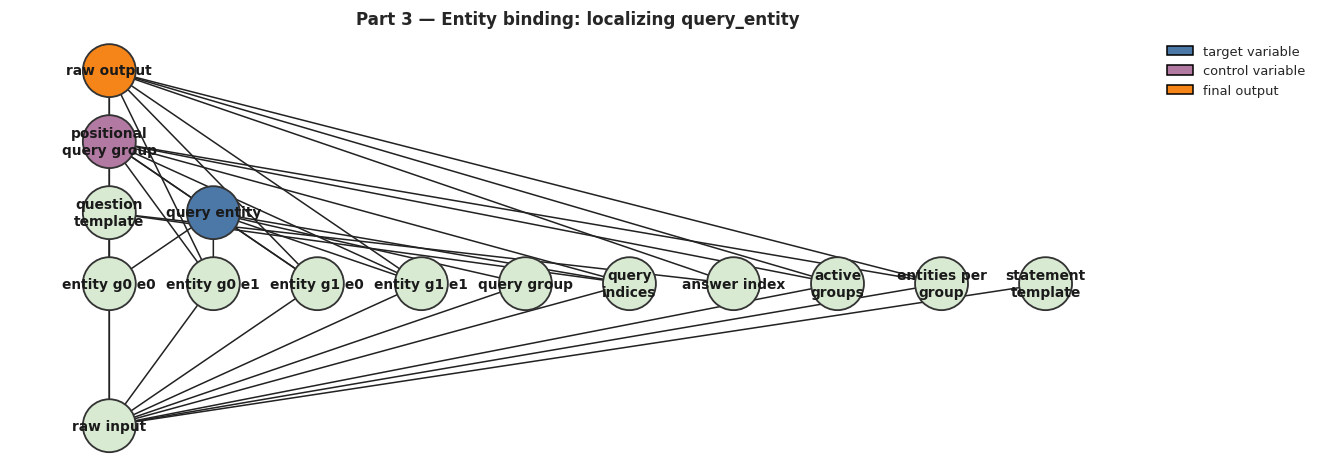


Quick sanity check on one example from each generator:


--- Part 3 generator sanity check — query_swap ---
base input:
  We will ask a question about the following sentences.  Tim loves bread, and Bob loves tea.  What does
  Bob love? Answer:
source input:
  We will ask a question about the following sentences.  Bob loves bread, and Tim loves tea.  What does
  Tim love? Answer:
variable values:
  - query_entity: base=('Bob',) | source=('Tim',) | CHANGED
  - positional_query_group: base=1 | source=1 | same
outputs:
  base output:   tea
  source output: tea
interventions:
  patch(query_entity)           -> bread
  patch(positional_query_group) -> tea

--- Part 3 generator sanity check — random ---
base input:
  We will ask a question about the following sentences.  Sue loves tea, and Ann loves soup.  What does
  Ann love? Answer:
source input:
  We will ask a question about the following sentences.  Pete loves soup, and Ann loves jam.  What does
  Ann love? Answer:
variable values:
  -

In [20]:
show_localization_view(
    positional_model,
    target_vars=["query_entity"],
    control_vars=["positional_query_group"],
    title="Part 3 — Entity binding: localizing query_entity",
)

# Two task-local generators for Part 3:
#   - `query_swap`: changes which entity is named in the question, keeps the
#     queried group fixed (Δquery_entity = 1, Δpositional_query_group = 0).
#   - `random`: reuses the task-code random generator, keeping only fully
#     filled examples. Intentionally messy baseline.
_eb_gens = make_entity_binding_generators(config, positional_model)
query_swap_pair = _eb_gens["query_swap"]
random_pair = _eb_gens["random"]

print("\nQuick sanity check on one example from each generator:\n")
for name, sampler in _eb_gens.items():
    ex = sampler()
    print_counterfactual_pair_text(
        ex, variables=["query_entity", "positional_query_group"],
        title=f"Part 3 generator sanity check — {name}", wrap=102,
    )
    base = ex["input"]
    cf = ex["counterfactual_inputs"][0]
    y_q = positional_model.run_interchange(base, {"query_entity": cf})["raw_output"]
    y_g = positional_model.run_interchange(base, {"positional_query_group": cf})["raw_output"]
    print("interventions:")
    print(f"  patch(query_entity)           -> {str(y_q).strip()}")
    print(f"  patch(positional_query_group) -> {str(y_g).strip()}")


### 📊 Step 3: Validate the entity-binding datasets before patching

This step mirrors the validation performed in Parts 1 and 2. Entity binding makes the design problem more visible because `query_entity` and `positional_query_group` are strongly correlated on ordinary prompts.

With target $V = \texttt{query\_entity}$ and alternative $W = \texttt{positional\_query\_group}$, we compare three datasets:

- 🎲 `random`,
- 🎯 `query_entity_targeted`, which enforces criteria (1) and (2),
- 🟣 `query_entity_isolated`, which enforces criteria (1), (2), and (3).

The dataset-level checks are the same three rates as before.

1. The rate at which `query_entity` differs between $b$ and $s$ (criterion 1).
2. The rate at which `patch(query_entity)` induces a non-trivial change in $Y$ relative to the base run (criterion 2).
3. The rate at which `patch(query_entity)` and `patch(positional_query_group)` produce different causal-model outputs (criterion 3).

We also print one confounding example drawn from `query_entity_targeted` and one non-confounding example drawn from `query_entity_isolated`. Because the structural correlation between $V$ and $W$ is strong in this task, the diagnostic stage carries more weight here than in the earlier parts.


Part 3 — Entity binding: change-rate table


,dataset,n,Δquery entity,Δpositional query group
0,query entity targeted,128,100.0%,53.9%
1,query entity isolated,128,100.0%,0.0%
2,random,128,89.1%,56.2%


Part 3 — Entity binding: effect-rate table


,dataset,n,patch(query entity),patch(positional query group)
0,query entity targeted,128,100.0%,53.9%
1,query entity isolated,128,100.0%,0.0%
2,random,128,89.1%,56.2%


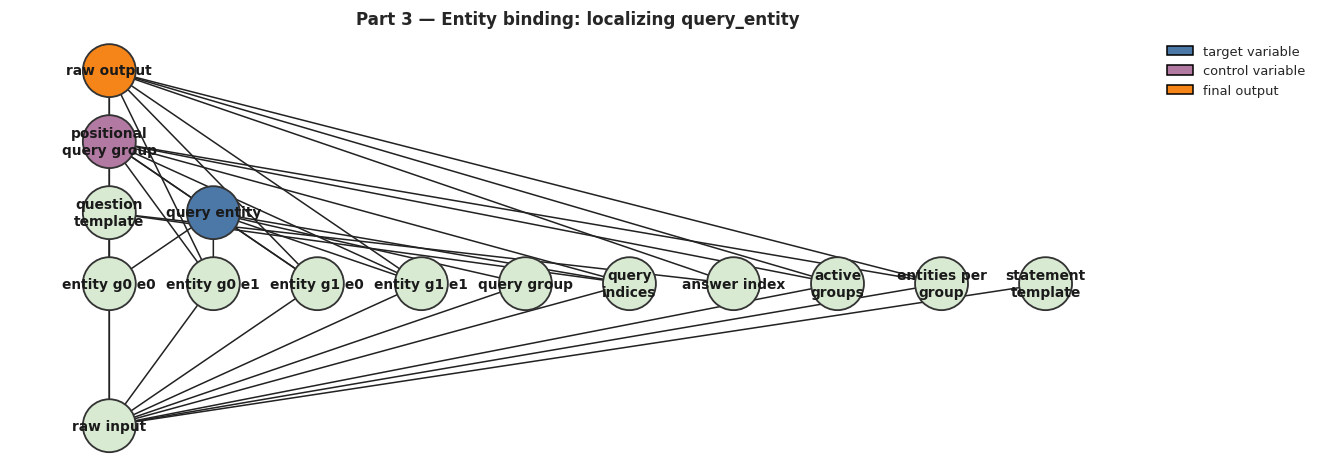

Part 3 — Entity binding: scorecard for query_entity


,dataset,n,Δ target (query entity),patch(query entity) changes output,Δ control (positional query group),patch(positional query group) changes output,separates query entity vs positional query group
0,query entity targeted,128,100.0%,100.0%,53.9%,53.9%,90.6%
1,query entity isolated,128,100.0%,100.0%,0.0%,0.0%,100.0%
2,random,128,89.1%,89.1%,56.2%,56.2%,85.9%


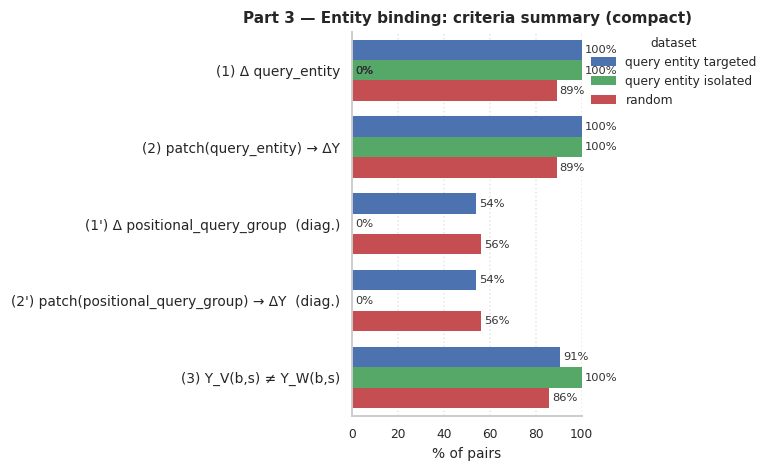


=== Part 3 — Localizing query_entity: one pair from each dataset ===

--- query entity targeted dataset — one example pair ---
base input:
  We will ask a question about the following sentences.  Tim loves pie, and Bob loves jam.  What does
  Tim love? Answer:
source input:
  We will ask a question about the following sentences.  Pete loves cake, and Kate loves bread.  What
  does Kate love? Answer:
variable values:
  - query_entity: base=('Tim',) | source=('Kate',) | CHANGED
  - positional_query_group: base=0 | source=1 | CHANGED
outputs:
  base output:   pie
  source output: bread
  patch(query_entity) -> UNKNOWN
  patch(positional_query_group)  -> jam

--- query entity isolated dataset — one example pair ---
base input:
  We will ask a question about the following sentences.  Kate loves bread, and Ann loves soup.  What
  does Kate love? Answer:
source input:
  We will ask a question about the following sentences.  Ann loves bread, and Kate loves soup.  What
  does Ann love? Answer:

In [21]:
N_ENTITY = 128
entity_datasets = {
    "query_entity_targeted": build_counterfactual_dataset(
        causal_model=positional_model, sampler=random_pair, n=N_ENTITY,
        target="query_entity", other="positional_query_group",
        require_distinguishability=False, require_other_fixed=False,
        max_attempts_per_example=400,
    ),
    "query_entity_isolated": build_counterfactual_dataset(
        causal_model=positional_model, sampler=query_swap_pair, n=N_ENTITY,
        target="query_entity", other="positional_query_group",
        require_distinguishability=True, require_other_fixed=True,
        max_attempts_per_example=400,
    ),
    "random": make_dataset(N_ENTITY, random_pair),
}

target, control = "query_entity", "positional_query_group"
display_change_rate_table(
    entity_datasets, [target, control],
    title="Part 3 — Entity binding: change-rate table",
)
display_effect_rate_table(
    positional_model, entity_datasets,
    {f"patch({target})": [target], f"patch({control})": [control]},
    title="Part 3 — Entity binding: effect-rate table",
)
show_localization_view(
    positional_model, target_vars=[target], control_vars=[control],
    title="Part 3 — Entity binding: localizing query_entity",
)
display_localization_scorecard(
    positional_model, entity_datasets,
    target_vars=[target], control_vars=[control],
    title="Part 3 — Entity binding: scorecard for query_entity",
)
plot_dataset_criteria_bars(
    positional_model, entity_datasets,
    target_vars=[target], control_vars=[control],
    title="Part 3 — Entity binding: criteria summary (compact)",
)

print_one_pair_per_dataset(
    entity_datasets,
    causal_model=positional_model,
    variables=[target, control],
    target=target, other=control,
    title="Part 3 — Localizing query_entity: one pair from each dataset",
)
print_confounding_and_nonconfounding(
    causal_model=positional_model,
    variables=[target, control],
    target=target, other=control,
    confounding_source=entity_datasets["query_entity_targeted"],
    nonconfounding_source=entity_datasets["query_entity_isolated"],
    title="Part 3 — Confounding vs non-confounding (query_entity vs positional_query_group)",
)


### 🧩 Worked minimal example: confounding vs non-confounding (entity binding)

Let $V=\texttt{query\_entity}$, the entity named in the question, and let $W=\texttt{positional\_query\_group}$, the group index used by the positional search.

**Base example.**

> Pete loves jam, and Ann loves pie.  
>  
> What does Ann love?  
> Answer:

In the base run, the queried entity is Ann, so $V=(\text{Ann},)$, and the question points to group $1$, so $W=1$. The output is $\text{pie}$.

**Confounding source.**

> Pete loves jam, and Ann loves pie.  
>  
> What does Pete love?  
> Answer:

Here both variables change: $V=(\text{Pete},)$ and $W=0$. This pair is **confounding** because the two interchanges make the same prediction. If we interchange on $V$, the base run now queries Pete, and the base bindings return $\text{jam}$. If we interchange on $W$, the base run is sent directly to group $0$, which also returns $\text{jam}$. So $Y_V(b,s)=Y_W(b,s)=\text{jam}$. This pair does not distinguish the two hypotheses.

**Non-confounding source.**

> Ann loves jam, and Pete loves pie.  
>  
> What does Pete love?  
> Answer:

Here the queried entity changes to Pete, so $V=(\text{Pete},)$, but the question still points to group $1$, so $W=1$ stays fixed. This pair is **non-confounding**. If we interchange on $V$, the base run now queries Pete, and the base bindings return $\text{jam}$. If we interchange on $W$, nothing changes at the group level, so the base run still returns $\text{pie}$. Thus $Y_V(b,s)=\text{jam}$ but $Y_W(b,s)=\text{pie}$. The two predictions differ, so this pair separates the two localization hypotheses.

### 🧠 Step 4: Patch the language model on the entity-binding task

Entity binding is structurally harder than MCQA and uses an older task implementation. In practice this tends to yield a stricter filtering stage and heatmaps with less concentrated structure. The main comparison is `query_entity_isolated` against `query_entity_targeted`, with `random` retained as a secondary baseline.


In [22]:
from causalab.tasks.entity_binding.experiment_config import get_checker

size_eb = 64
entity_counterfactual_datasets = {
    "query_entity_targeted": entity_datasets["query_entity_targeted"][:size_eb],
    "query_entity_isolated": entity_datasets["query_entity_isolated"][:size_eb],
    "random": entity_datasets["random"][: max(size_eb, min(len(entity_datasets["random"]), 2 * size_eb))],
}

entity_filtered = filter_and_report(
    datasets=entity_counterfactual_datasets,
    pipeline=pipeline_eb, causal_model=positional_model,
    metric=get_checker(), batch_size=min(FILTER_BATCH_SIZE, 64),
    label="entity", min_kept_warn=8,
)

# Intervention sites: the last token of each entity in every group's
# statement, the last token of the queried entity in the question, and
# the last token of the prompt.
eb_sites = build_entity_binding_token_positions(config, pipeline_eb)
token_positions_eb = eb_sites["positions"]
_eb_pos_id_to_label = eb_sites["label_map"]

diagnose_entity_binding_sites(
    filtered_datasets=entity_filtered, pipeline=pipeline_eb,
    config=config, site_panel=eb_sites,
)

layers_eb = default_layers(pipeline_eb, _device)


[entity] Filtering datasets (keep only examples the LM gets right)...


  query_entity_targeted: kept 13/64 examples


  query_entity_isolated: kept 24/64 examples


  random: kept 20/128 examples

Intervention sites resolved on one filtered base example:
        g0_e0_stmt -> idx=[237]  tokens='ue'
        g0_e1_stmt -> idx=[239]  tokens=' tea'
        g1_e0_stmt -> idx=[242]  tokens=' Tim'
        g1_e1_stmt -> idx=[244]  tokens=' pie'
      both_e1_swap -> idx=[239, 244]  tokens=' tea' | ' pie'
    query_entity_q -> idx=[250]  tokens=' Sue'
        last_token -> idx=[255]  tokens=':'

Structured parser resolved every site without falling back to last_token.


In [23]:
results_eb, targets_eb = run_patching_for_datasets(
    pipeline=pipeline_eb,
    causal_model=positional_model,
    datasets=entity_filtered,
    token_positions=token_positions_eb,
    target_variable_groups=[("query_entity",)],
    metric=get_checker(),
    batch_size=min(PATCH_BATCH_SIZE, 64),
    layers=layers_eb,
)
print("\nInterventions complete and scores computed.")



Running patching on 'query_entity_targeted' (13 examples)


Running interventions: 100%|██████████| 91/91 [00:51<00:00,  1.76it/s]



Running patching on 'query_entity_isolated' (24 examples)


Running interventions: 100%|██████████| 91/91 [01:13<00:00,  1.23it/s]



Running patching on 'random' (20 examples)


Running interventions: 100%|██████████| 91/91 [01:06<00:00,  1.37it/s]


Interventions complete and scores computed.


### 📈 Step 5: Read the entity-binding heatmaps

**What are we trying to localize?**  
The target is $V=\texttt{query\_entity}$: the entity named in the question.  
The alternative is $W=\texttt{positional\_query\_group}$: the group index the question points to.

These two variables are often correlated on ordinary prompts. That is why **criterion (3)** matters here. A high IIA score is only strong evidence for localizing $V$ when the dataset can distinguish $V$ from $W$.

---

**What do the heatmap columns mean?**  
Each column is one token position, or one small set of token positions, that we patch.

For the example prompt

> `"We will ask a question about the following sentences.\n\nPete loves jam, and Ann loves pie.\n\nWhat does Pete love?\nAnswer:"`

the columns are:

- **`g0_e0_stmt`**: the last token of entity $e_0$ in group 0's statement, for example ` Pete`
- **`g0_e1_stmt`**: the last token of entity $e_1$ in group 0's statement, for example ` jam`
- **`g1_e0_stmt`**: the last token of entity $e_0$ in group 1's statement, for example ` Ann`
- **`g1_e1_stmt`**: the last token of entity $e_1$ in group 1's statement, for example ` pie`
- **`both_e1_swap`**: the two $e_1$ statement tokens patched together, with the source order reversed so the intervention swaps the group-level $e_1$ representations
- **`query_entity_q`**: the last token of the queried entity in the question, for example ` Pete` in `What does Pete love?`
- **`last_token`**: the final token of the prompt, the `:` in `Answer:`

A useful detail: the same word can appear in both the statement and the question, but these are treated as different token sites. The parser `get_entity_token_indices_structured` keeps them separate, so `g1_e0_stmt` and `query_entity_q` can refer to different positions even when they decode to the same word.

---

We look at two comparisons:

- **`query_entity_isolated` vs `query_entity_targeted`**  
  This is the main one. It asks whether enforcing criterion (3), that is, making the dataset distinguish $V$ from $W$, removes signal that was previously compatible with both hypotheses.

- **`query_entity_isolated` vs `random`**  
  This is a sanity check. It asks whether the designed dataset concentrates signal more clearly than an unconstrained baseline.

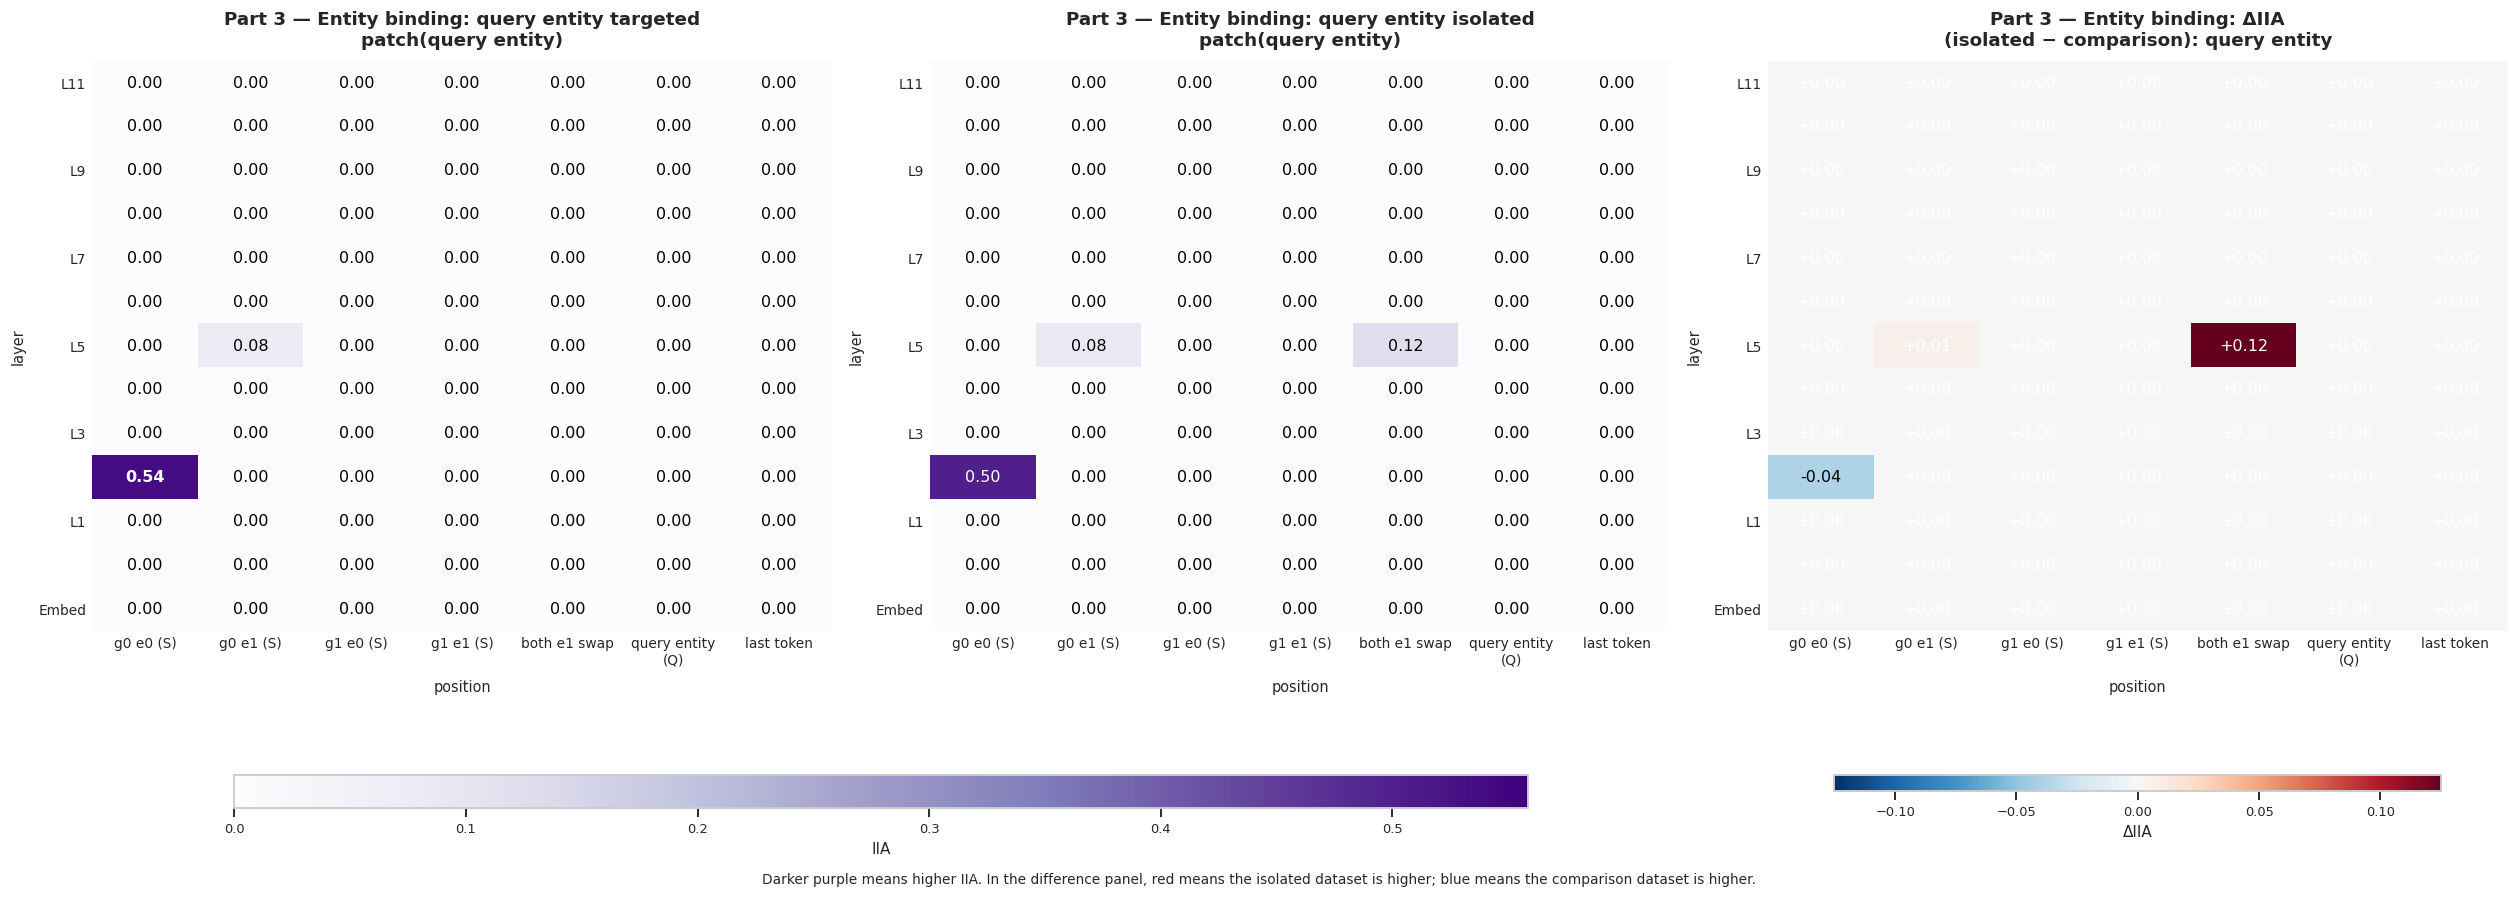

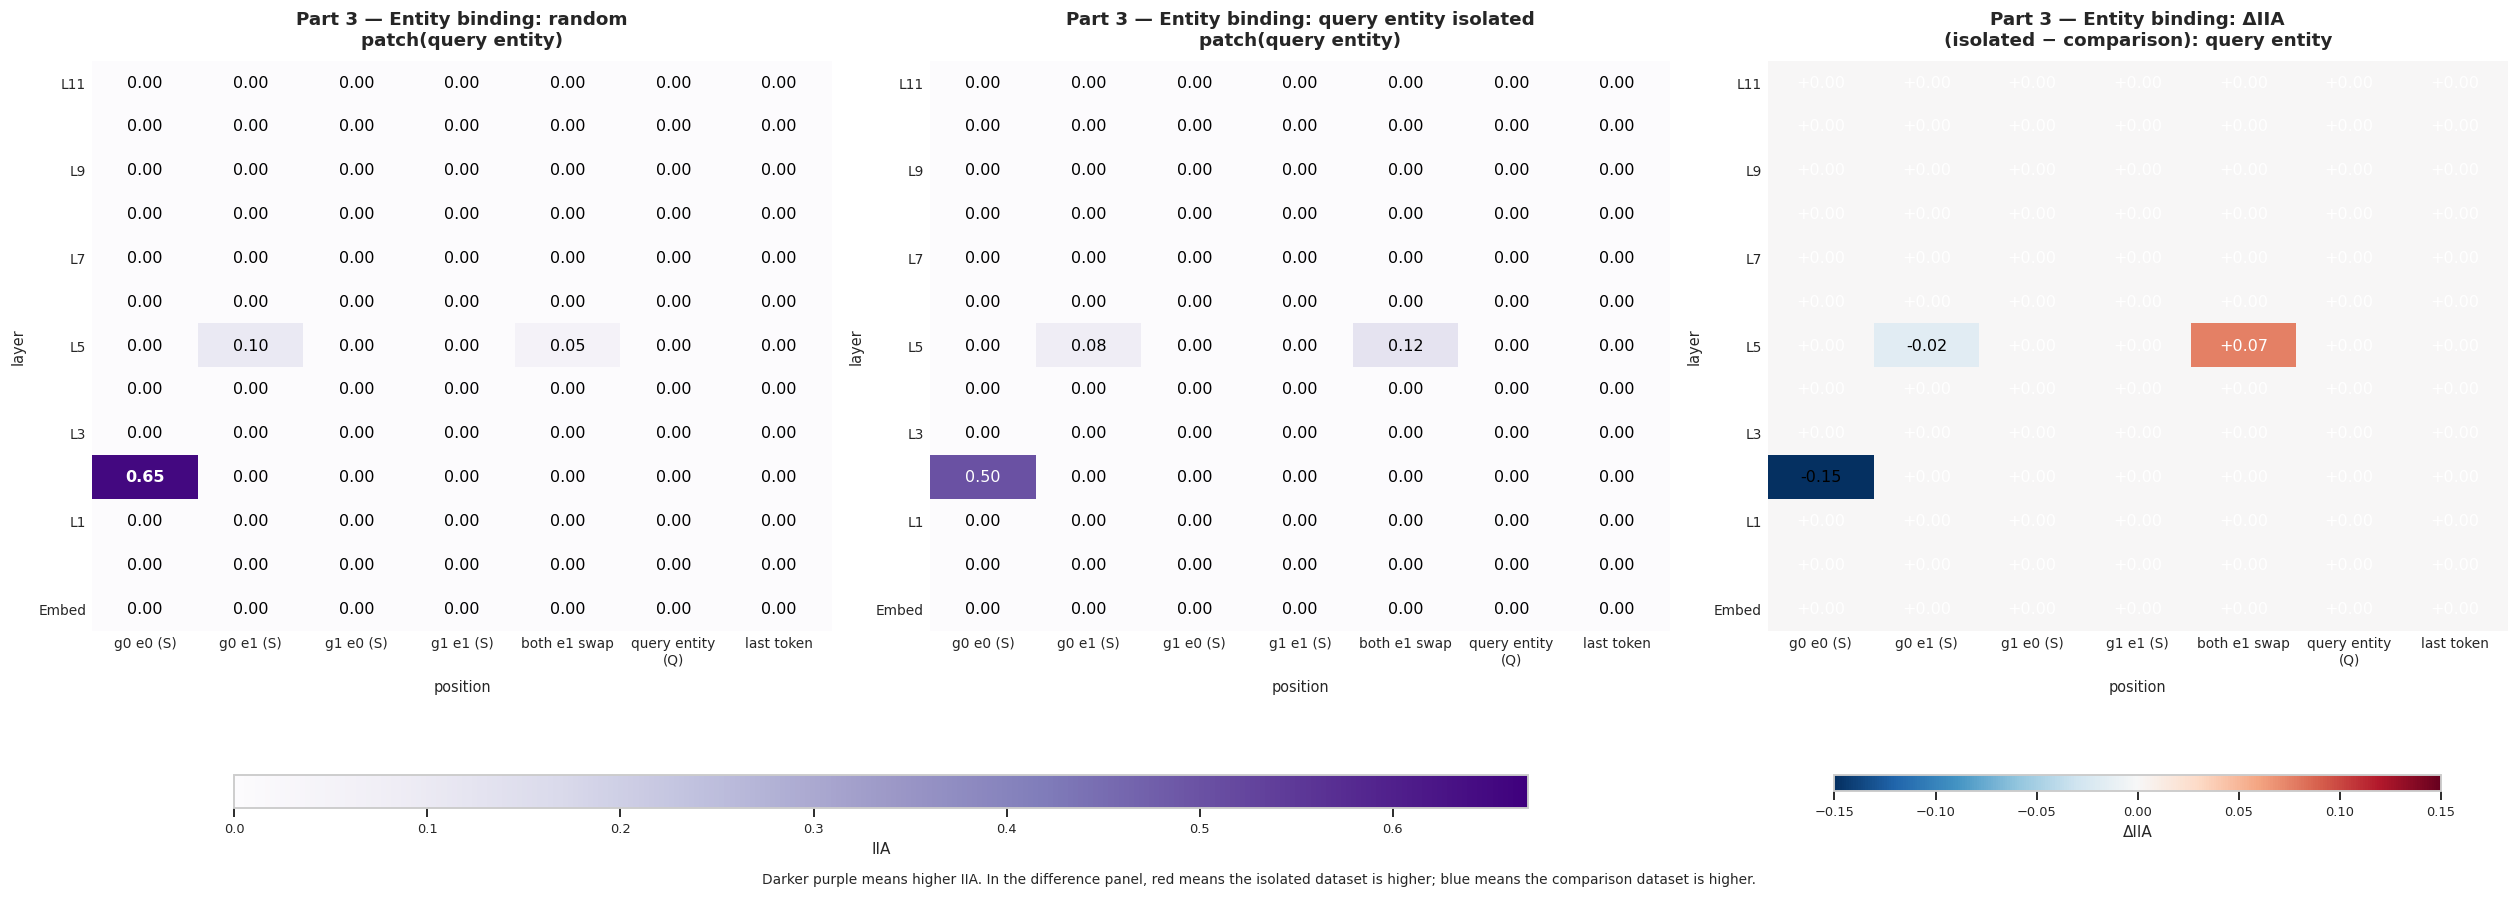

In [24]:
plot_iia_target_control_random(
    results=results_eb,
    targets=targets_eb,
    var_name="query_entity",
    dataset_targeted="query_entity_isolated",
    dataset_control="query_entity_targeted",
    dataset_random="random",
    pos_id_to_label=_eb_pos_id_to_label,
    title_prefix="Part 3 — Entity binding: ",
)

In [25]:
print("Part 3 keeps a single localization target (query_entity), so no second heatmap is plotted.")

Part 3 keeps a single localization target (query_entity), so no second heatmap is plotted.


## 🌟 Wrap-up

In this notebook, we treated **counterfactual dataset design** as part of the interpretability method itself, not as a separate preprocessing step. The main lesson is that an intervention is only as informative as the **base-source pairs** we use to evaluate it.

Across the three tasks, we saw the same pattern. A good counterfactual pair must first change the target variable. Moreover, that change must induce a **different predicted output** at the level of the causal model. But even that is not enough. If the same pair is also compatible with a competing localization hypothesis, then a high IIA score does not yet tell us which variable has been localized.

This is why **distinguishability** matters. We do not know in advance where a target variable is realized in the network. That is what the intervention analysis is trying to discover. So before reading a IIA heatmap, we need to know whether the dataset can actually distinguish the target variable from nearby alternatives. When it cannot, the low-level result may look sharp while still remaining ambiguous.

The broader point is methodological. 

Designing counterfactual datasets is the causal-interpretability analogue of designing good minimal pairs in behavioral analysis. In both cases, the goal is controlled variation. We change what matters, hold fixed what we can, and check in advance what conclusion the resulting contrast can support.

So the takeaway is not just that some datasets are better than others. It is that **counterfactual evaluation has to be designed around the explanatory question we want to answer**. When the dataset is well designed, intervention results become easier to interpret, easier to compare, and more useful as evidence about what computation a model is actually implementing.